# 지역사회건강조사(CHS) 2015-2025 EDA
## 나이 / 지역 / 연도 / 성별 × 건강 관계 분석

**데이터**: 보건복지부 지역사회건강조사 (Community Health Survey)  
**기간**: 2015~2025년 (연 약 228,000~231,000명)  
**총 표본**: 약 250만 건

### 분석 목차
1. 환경 설정 & 데이터 로딩  
2. 결측치 처리  
3. 파생변수 생성  
4. 기술통계 & 표본 개요  
5. 연도별 트렌드 (2015-2025)  
6. 나이별 건강 패턴  
7. 지역별 건강 격차  
8. 성별 건강 차이  
9. 건강행동 × 건강결과  
10. 정신건강 위험요인  
11. 상관관계 분석  
12. 다차원 분석 (성별×나이, COVID-19 전후)


## 1. 환경 설정 & 데이터 로딩

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──
import matplotlib.font_manager as fm
from matplotlib import rc
import os

_font_candidates = [
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf',  # macOS 기본
    '/Users/sim-yujin/Library/Fonts/NanumGothicEco.ttf',   # 설치된 나눔폰트
    '/Library/Fonts/NanumGothic.ttf',
    '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',      # Linux
]
_font_path = next((p for p in _font_candidates if os.path.exists(p)), None)
if _font_path:
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    rc('font', family=_font_name)
    print(f"한글 폰트 설정: {_font_name} ({_font_path})")
else:
    rc('font', family='AppleGothic')
    print("경고: 지정된 한글 폰트를 찾지 못해 AppleGothic 기본값 사용")
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

BASE = '/Users/sim-yujin/[3-2] SocialIntelligence/팀프로젝트/socialInteligence/health/data/'

# 2015-2018: 알파벳 지역코드 → 숫자코드 매핑
CITY_TO_CODE = {
    'A':11,'B':26,'C':27,'D':28,'E':29,'F':30,'G':31,'H':36,
    'I':41,'J':42,'K':43,'L':44,'M':45,'N':46,'O':47,'P':48,'Q':50
}

REGION_NAMES = {
    11:'서울',26:'부산',27:'대구',28:'인천',29:'광주',30:'대전',
    31:'울산',36:'세종',41:'경기',42:'강원',43:'충북',44:'충남',
    45:'전북',46:'전남',47:'경북',48:'경남',50:'제주'
}

COMMON_HEALTH_VARS = [
    'qoa_01z1',  # 주관적 건강상태 (1=매우좋음 ~ 5=매우나쁨)
    'dra_01z1',  # 음주여부 (1=마심, 2=안마심)
    'mta_01z1',  # 스트레스 인지 (1=대단히많이 ~ 4=거의없음)
    'mtb_01z1',  # 우울증상 경험 (1=있음, 2=없음)
    'obb_01z1',  # 비만도 BMI기반 (1~4; 4=비만 추정)
    'sca_01z1',  # 사회적자본-신뢰 (1=신뢰, 2=불신)
    'ora_01z1',  # 구강건강상태 (1=매우좋음 ~ 5=매우나쁨)
    'sma_08z1',  # 흡연관련
    'sob_01z1',  # 사회적지지1
    'sob_02z1',  # 사회적지지2
    'ira_01z1',  # 미충족의료 (1=있음, 2=없음)
]

EXTRA_VARS_2019 = [
    'hya_19z1',  # 고혈압 (1=없음, 2=있음)
    'dia_04z1',  # 당뇨 진단 여부 (1=있음, 2=없음)
    'sma_01z1',  # 현재 흡연
    'smf_01z1',  # 흡연경험여부 (2023+)
    'pha_04z1',  # 걷기 일수/주 (0~7)
    'nua_01z2',  # 영양섭취 부족 여부
    'cva_12z1',  # 뇌졸중 진단
    'cva_17z1',  # 심근경색 진단
    'mya_14z1',  # 관절염 진단
    'osa_04z1',  # 골다공증 진단
    'sra_01z3',  # 신장기능
    'mtb_07a1','mtb_07b1','mtb_07c1','mtb_07d1','mtb_07e1',
    'mtb_07f1','mtb_07g1','mtb_07h1','mtb_07i1',  # PHQ-9 항목
    'irb_01z1',  # 미충족의료 (다른 버전)
]

print("상수 설정 완료")
print(f"데이터 경로: {BASE}")
print(f"분석 대상 연도: 2015-2025 ({11}개년)")
print(f"전체 공통 건강변수: {len(COMMON_HEALTH_VARS)}개")
print(f"2019+ 추가변수: {len(EXTRA_VARS_2019)}개")


한글 폰트 설정: AppleGothic (/System/Library/Fonts/Supplemental/AppleGothic.ttf)
상수 설정 완료
데이터 경로: /Users/sim-yujin/[3-2] SocialIntelligence/팀프로젝트/socialInteligence/health/data/
분석 대상 연도: 2015-2025 (11개년)
전체 공통 건강변수: 11개
2019+ 추가변수: 21개


In [2]:
# ══ 전체 연도 데이터 로딩 & 병합 ══
dfs_all = []
for yr in range(2015, 2026):
    y2 = str(yr)[2:]
    df = pd.read_csv(BASE+f'chs{y2}_all.csv', low_memory=False)
    df.columns = df.columns.str.lower()

    # 연도 컬럼 통일
    for yc in ['josa_year', 'examin_year', 'examin_code']:
        if yc in df.columns:
            df.rename(columns={yc: 'year'}, inplace=True)
            break
    if 'year' not in df.columns:
        df['year'] = yr

    # 지역 컬럼 통일
    if 'city_cd' in df.columns:
        df['region'] = df['city_cd'].map(CITY_TO_CODE)
    elif 'ctprvn_code' in df.columns:
        df.rename(columns={'ctprvn_code': 'region'}, inplace=True)

    keep = ['year', 'age', 'sex', 'region'] +            [c for c in COMMON_HEALTH_VARS if c in df.columns]
    dfs_all.append(df[keep])

df_all = pd.concat(dfs_all, ignore_index=True)
df_all['year'] = df_all['year'].astype(int)
df_all['region'] = pd.to_numeric(df_all['region'], errors='coerce')

# ══ 2019-2025 데이터 로딩 (추가 변수 포함) ══
dfs_new = []
for yr in range(2019, 2026):
    y2 = str(yr)[2:]
    df = pd.read_csv(BASE+f'chs{y2}_all.csv', low_memory=False)
    df.columns = df.columns.str.lower()

    for yc in ['examin_year', 'examin_code']:
        if yc in df.columns:
            df.rename(columns={yc: 'year'}, inplace=True)
            break
    if 'ctprvn_code' in df.columns:
        df.rename(columns={'ctprvn_code': 'region'}, inplace=True)

    keep = ['year', 'age', 'sex', 'region'] +            [c for c in COMMON_HEALTH_VARS + EXTRA_VARS_2019 if c in df.columns]
    keep = list(dict.fromkeys(keep))
    dfs_new.append(df[keep])

df_new = pd.concat(dfs_new, ignore_index=True)
df_new['year'] = df_new['year'].astype(int)

print(f"[df_all]  전체 연도 2015-2025: {df_all.shape[0]:,}행 × {df_all.shape[1]}열")
print(f"[df_new]  2019-2025 풍부한 변수: {df_new.shape[0]:,}행 × {df_new.shape[1]}열")
print(f"\n연도별 표본 수:")
print(df_all.groupby('year').size().to_string())


[df_all]  전체 연도 2015-2025: 2,528,221행 × 15열
[df_new]  2019-2025 풍부한 변수: 1,614,490행 × 36열

연도별 표본 수:
year
2015    228558
2016    228452
2017    228381
2018    228340
2019    229099
2020    229269
2021    229242
2022    231785
2023    231752
2024    231728
2025    231615


## 2. 결측치 처리

CHS는 **7=모름, 8=비해당, 9=무응답** (2자리: 77/88/99, 3자리: 888 등)을 결측 코드로 사용합니다.
각 변수의 유효 범위를 지정해 범위 외 값은 NaN으로 처리합니다.

In [3]:
# 변수별 유효 범위 정의 (CHS 코드북 기준)
VAR_VALID_RANGE = {
    # ── 전체 공통 ──
    'qoa_01z1': (1, 5),   # 주관적 건강: 1~5
    'dra_01z1': (1, 2),   # 음주: 1=예, 2=아니오
    'mta_01z1': (1, 4),   # 스트레스: 1~4
    'mtb_01z1': (1, 2),   # 우울증상: 1=있음, 2=없음
    'obb_01z1': (1, 4),   # 비만도: 1~4
    'sca_01z1': (1, 2),   # 사회적자본: 1~2
    'ora_01z1': (1, 5),   # 구강건강: 1~5
    'sma_08z1': (1, 2),   # 흡연관련: 1~2
    'sob_01z1': (1, 2),
    'sob_02z1': (1, 2),
    'ira_01z1': (1, 2),   # 미충족의료
    # ── 2019+ ──
    'hya_19z1': (1, 2),   # 고혈압: 1=없음, 2=있음
    'dia_04z1': (1, 2),   # 당뇨 진단: 1=있음, 2=없음
    'sma_01z1': (1, 3),   # 흡연: 1=매일, 2=가끔, 3=과거 (8=비해당은 NaN 처리)
    'smf_01z1': (1, 2),   # 흡연경험: 1=있음, 2=없음
    'pha_04z1': (0, 7),   # 걷기 일수
    'nua_01z2': (1, 4),   # 영양섭취
    'cva_12z1': (1, 2),   # 뇌졸중
    'cva_17z1': (1, 2),   # 심근경색
    'mya_14z1': (1, 2),   # 관절염
    'osa_04z1': (1, 2),   # 골다공증
    'sra_01z3': (1, 3),   # 신장기능
    'irb_01z1': (1, 2),   # 미충족의료(신버전)
    **{f'mtb_07{x}1': (1, 3) for x in 'abcdefghi'},  # PHQ-9 항목: 1~3
}

def clean_by_range(df, var_dict):
    df = df.copy()
    for col, (vmin, vmax) in var_dict.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].where((df[col] >= vmin) & (df[col] <= vmax))
    return df

df_all = clean_by_range(df_all, VAR_VALID_RANGE)
df_new = clean_by_range(df_new, VAR_VALID_RANGE)

# 결측률 확인
print("=== df_all 주요 변수 결측률 ===")
miss = df_all[COMMON_HEALTH_VARS].isnull().mean().mul(100).round(1)
print(miss.to_string())
print()
extra_cols = [c for c in EXTRA_VARS_2019 if c in df_new.columns]
print("=== df_new 2019+ 추가변수 결측률 ===")
miss2 = df_new[extra_cols].isnull().mean().mul(100).round(1)
print(miss2.to_string())


=== df_all 주요 변수 결측률 ===
qoa_01z1     0.0
dra_01z1     0.0
mta_01z1     0.0
mtb_01z1     0.0
obb_01z1     0.0
sca_01z1     0.1
ora_01z1     0.0
sma_08z1    16.8
sob_01z1    94.3
sob_02z1    17.5
ira_01z1     0.0

=== df_new 2019+ 추가변수 결측률 ===
hya_19z1     0.2
dia_04z1     0.0
sma_01z1    26.2
smf_01z1    56.9
pha_04z1     0.0
nua_01z2     0.0
cva_12z1     2.7
cva_17z1     4.2
mya_14z1     5.8
osa_04z1    85.7
sra_01z3     0.0
mtb_07a1     2.9
mtb_07b1     1.5
mtb_07c1     7.1
mtb_07d1     5.0
mtb_07e1     2.1
mtb_07f1     0.7
mtb_07g1     0.7
mtb_07h1     0.5
mtb_07i1     0.6
irb_01z1    42.9


## 3. 파생변수 생성

In [4]:
# ── 나이 그룹 ──
age_bins   = [18, 29, 39, 49, 59, 69, 120]
age_labels = ['19-29세', '30-39세', '40-49세', '50-59세', '60-69세', '70세이상']
df_all['age_group'] = pd.cut(df_all['age'], bins=age_bins, labels=age_labels)
df_new['age_group'] = pd.cut(df_new['age'], bins=age_bins, labels=age_labels)

# ── 성별/지역 라벨 ──
df_all['성별'] = df_all['sex'].map({1:'남성', 2:'여성'})
df_new['성별'] = df_new['sex'].map({1:'남성', 2:'여성'})
df_all['지역'] = df_all['region'].map(REGION_NAMES)
df_new['지역'] = df_new['region'].map(REGION_NAMES)

# ── 이진 건강 지표 파생 ──
for df in [df_all, df_new]:
    # 주관적 건강 나쁨 (4=나쁨, 5=매우나쁨)
    df['건강나쁨'] = (df['qoa_01z1'] >= 4).astype(float).where(df['qoa_01z1'].notna())
    # 음주
    df['음주'] = (df['dra_01z1'] == 1).astype(float).where(df['dra_01z1'].notna())
    # 스트레스 많음 (1=대단히많이, 2=많이)
    df['스트레스_많음'] = (df['mta_01z1'] <= 2).astype(float).where(df['mta_01z1'].notna())
    # 우울증상 경험
    df['우울증상'] = (df['mtb_01z1'] == 1).astype(float).where(df['mtb_01z1'].notna())
    # 비만 (obb_01z1==4; 4=비만으로 추정)
    df['비만'] = (df['obb_01z1'] == 4).astype(float).where(df['obb_01z1'].notna())
    # 미충족의료
    df['미충족의료'] = (df['ira_01z1'] == 1).astype(float).where(df['ira_01z1'].notna())

# ── 2019+ 추가 파생변수 ──
if 'hya_19z1' in df_new.columns:
    df_new['고혈압'] = (df_new['hya_19z1'] == 2).astype(float).where(df_new['hya_19z1'].notna())
if 'dia_04z1' in df_new.columns:
    df_new['당뇨'] = (df_new['dia_04z1'] == 1).astype(float).where(df_new['dia_04z1'].notna())
if 'cva_12z1' in df_new.columns:
    df_new['뇌졸중'] = (df_new['cva_12z1'] == 2).astype(float).where(df_new['cva_12z1'].notna())
if 'cva_17z1' in df_new.columns:
    df_new['심근경색'] = (df_new['cva_17z1'] == 2).astype(float).where(df_new['cva_17z1'].notna())
if 'mya_14z1' in df_new.columns:
    df_new['관절염'] = (df_new['mya_14z1'] == 2).astype(float).where(df_new['mya_14z1'].notna())
if 'osa_04z1' in df_new.columns:
    df_new['골다공증'] = (df_new['osa_04z1'] == 1).astype(float).where(df_new['osa_04z1'].notna())
if 'pha_04z1' in df_new.columns:
    df_new['걷기_주3일이상'] = (df_new['pha_04z1'] >= 3).astype(float).where(df_new['pha_04z1'].notna())

# PHQ-9 총점 (9개 항목 합산; 항목 범위 1~3 → 0~2로 변환 후 합산 = 0~18)
phq_cols = [f'mtb_07{x}1' for x in 'abcdefghi']
avail_phq = [c for c in phq_cols if c in df_new.columns]
if avail_phq:
    df_new['PHQ9_총점'] = (df_new[avail_phq] - 1).sum(axis=1)
    df_new['PHQ9_총점'] = df_new['PHQ9_총점'].where(df_new[avail_phq].notna().all(axis=1))
    df_new['우울위험'] = (df_new['PHQ9_총점'] >= 10).astype(float).where(df_new['PHQ9_총점'].notna())

# 흡연 통합 지표 (2019+)
df_new['흡연'] = np.nan
if 'smf_01z1' in df_new.columns:
    mask23 = df_new['year'] >= 2023
    df_new.loc[mask23, '흡연'] = (df_new.loc[mask23, 'smf_01z1'] == 1).astype(float)
    df_new.loc[mask23, '흡연'] = df_new.loc[mask23, '흡연'].where(df_new.loc[mask23, 'smf_01z1'].notna())
if 'sma_01z1' in df_new.columns:
    mask19_22 = df_new['year'].between(2019, 2022)
    # sma_01z1: 1=매일, 2=가끔 → 흡연; NaN(=8비해당) → 비흡연
    df_new.loc[mask19_22, '흡연'] = df_new.loc[mask19_22, 'sma_01z1'].notna().astype(float)

print("파생변수 생성 완료")
print("\n2019-2025 이진 지표 평균 (비율):")
binary_cols = ['건강나쁨','음주','스트레스_많음','우울증상','비만','고혈압','당뇨',
               '뇌졸중','심근경색','관절염','걷기_주3일이상','흡연']
avail_bin = [c for c in binary_cols if c in df_new.columns]
print(df_new[avail_bin].mean().mul(100).round(1).to_string())


파생변수 생성 완료

2019-2025 이진 지표 평균 (비율):
건강나쁨        18.3
음주          80.8
스트레스_많음     21.4
우울증상         6.8
비만          37.9
고혈압         34.9
당뇨          13.1
뇌졸중         13.7
심근경색        24.5
관절염         39.0
걷기_주3일이상    13.4
흡연          73.8


## 4. 기술통계 & 표본 개요

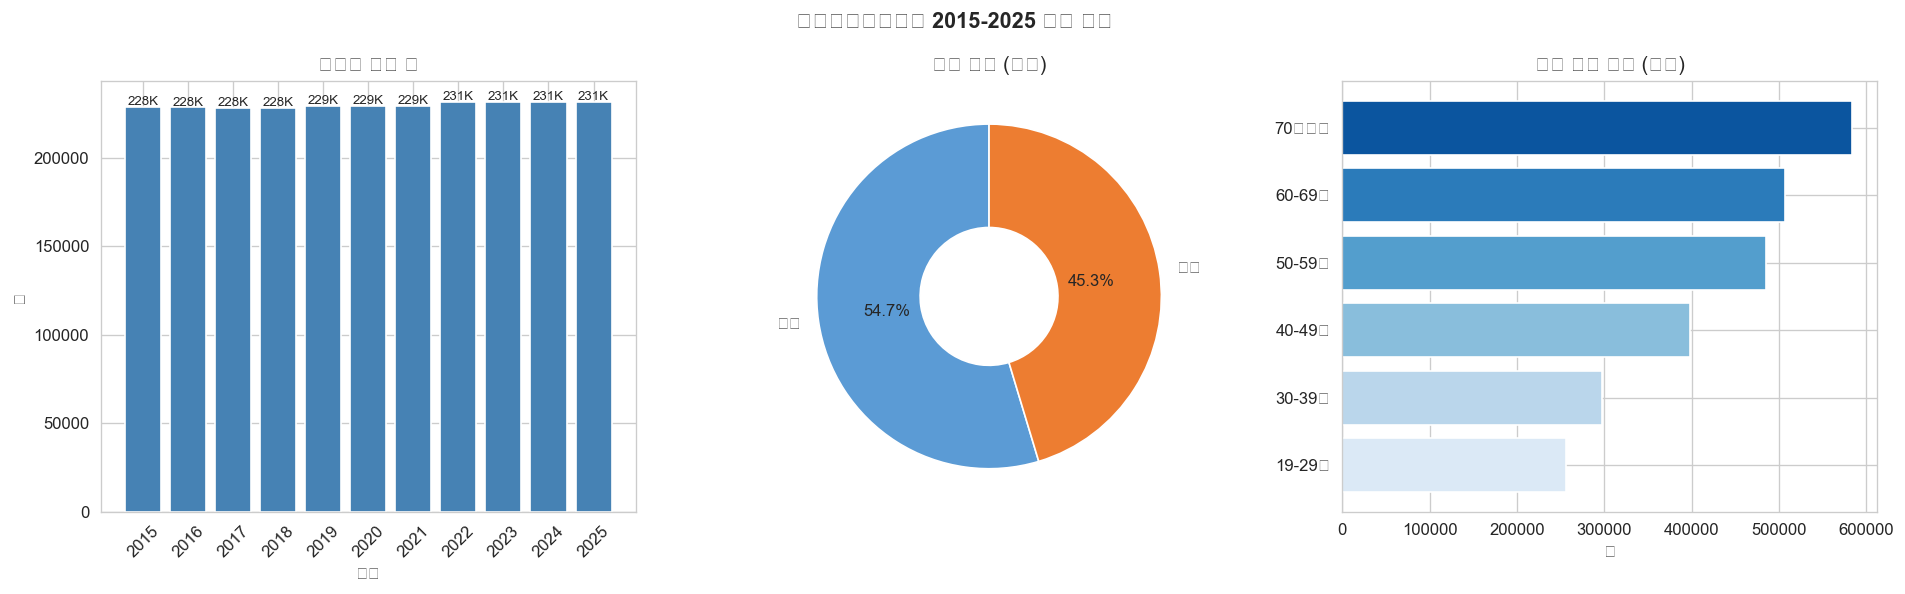


=== 주요 건강 지표 전체 평균 ===
  건강나쁨(%)             : 19.3%
  음주율(%)              : 81.4%
  스트레스많음(%)           : 22.5%
  우울증상(%)             : 6.6%
  비만(%)               : 39.5%
  미충족의료(%)            : 6.5%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 연도별 표본 수
yr_cnt = df_all.groupby('year').size()
axes[0].bar(yr_cnt.index, yr_cnt.values, color='steelblue', edgecolor='white')
for x, v in zip(yr_cnt.index, yr_cnt.values):
    axes[0].text(x, v+1000, f'{v//1000}K', ha='center', fontsize=8)
axes[0].set_title('연도별 표본 수')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('명')
axes[0].set_xticks(yr_cnt.index)
axes[0].set_xticklabels(yr_cnt.index, rotation=45)

# 성별 분포 (파이)
gender_cnt = df_all['성별'].value_counts()
axes[1].pie(gender_cnt.values, labels=gender_cnt.index,
            autopct='%1.1f%%', colors=['#5B9BD5','#ED7D31'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[1].set_title('성별 분포 (전체)')

# 나이 그룹 분포
age_cnt = df_all['age_group'].value_counts().sort_index()
bars = axes[2].barh(range(len(age_cnt)), age_cnt.values,
                     color=sns.color_palette('Blues', len(age_cnt)))
axes[2].set_yticks(range(len(age_cnt)))
axes[2].set_yticklabels(age_cnt.index)
axes[2].set_title('나이 그룹 분포 (전체)')
axes[2].set_xlabel('명')

plt.suptitle('지역사회건강조사 2015-2025 표본 개요', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 주요 지표 전체 분포
print("\n=== 주요 건강 지표 전체 평균 ===")
key_indicators = {
    '건강나쁨(%)': df_all['건강나쁨'].mean()*100,
    '음주율(%)': df_all['음주'].mean()*100,
    '스트레스많음(%)': df_all['스트레스_많음'].mean()*100,
    '우울증상(%)': df_all['우울증상'].mean()*100,
    '비만(%)': df_all['비만'].mean()*100,
    '미충족의료(%)': df_all['미충족의료'].mean()*100,
}
for k, v in key_indicators.items():
    print(f"  {k:20s}: {v:.1f}%")


## 5. 연도별 건강 트렌드 (2015-2025)

11년간 주요 건강 지표의 변화를 추적합니다.

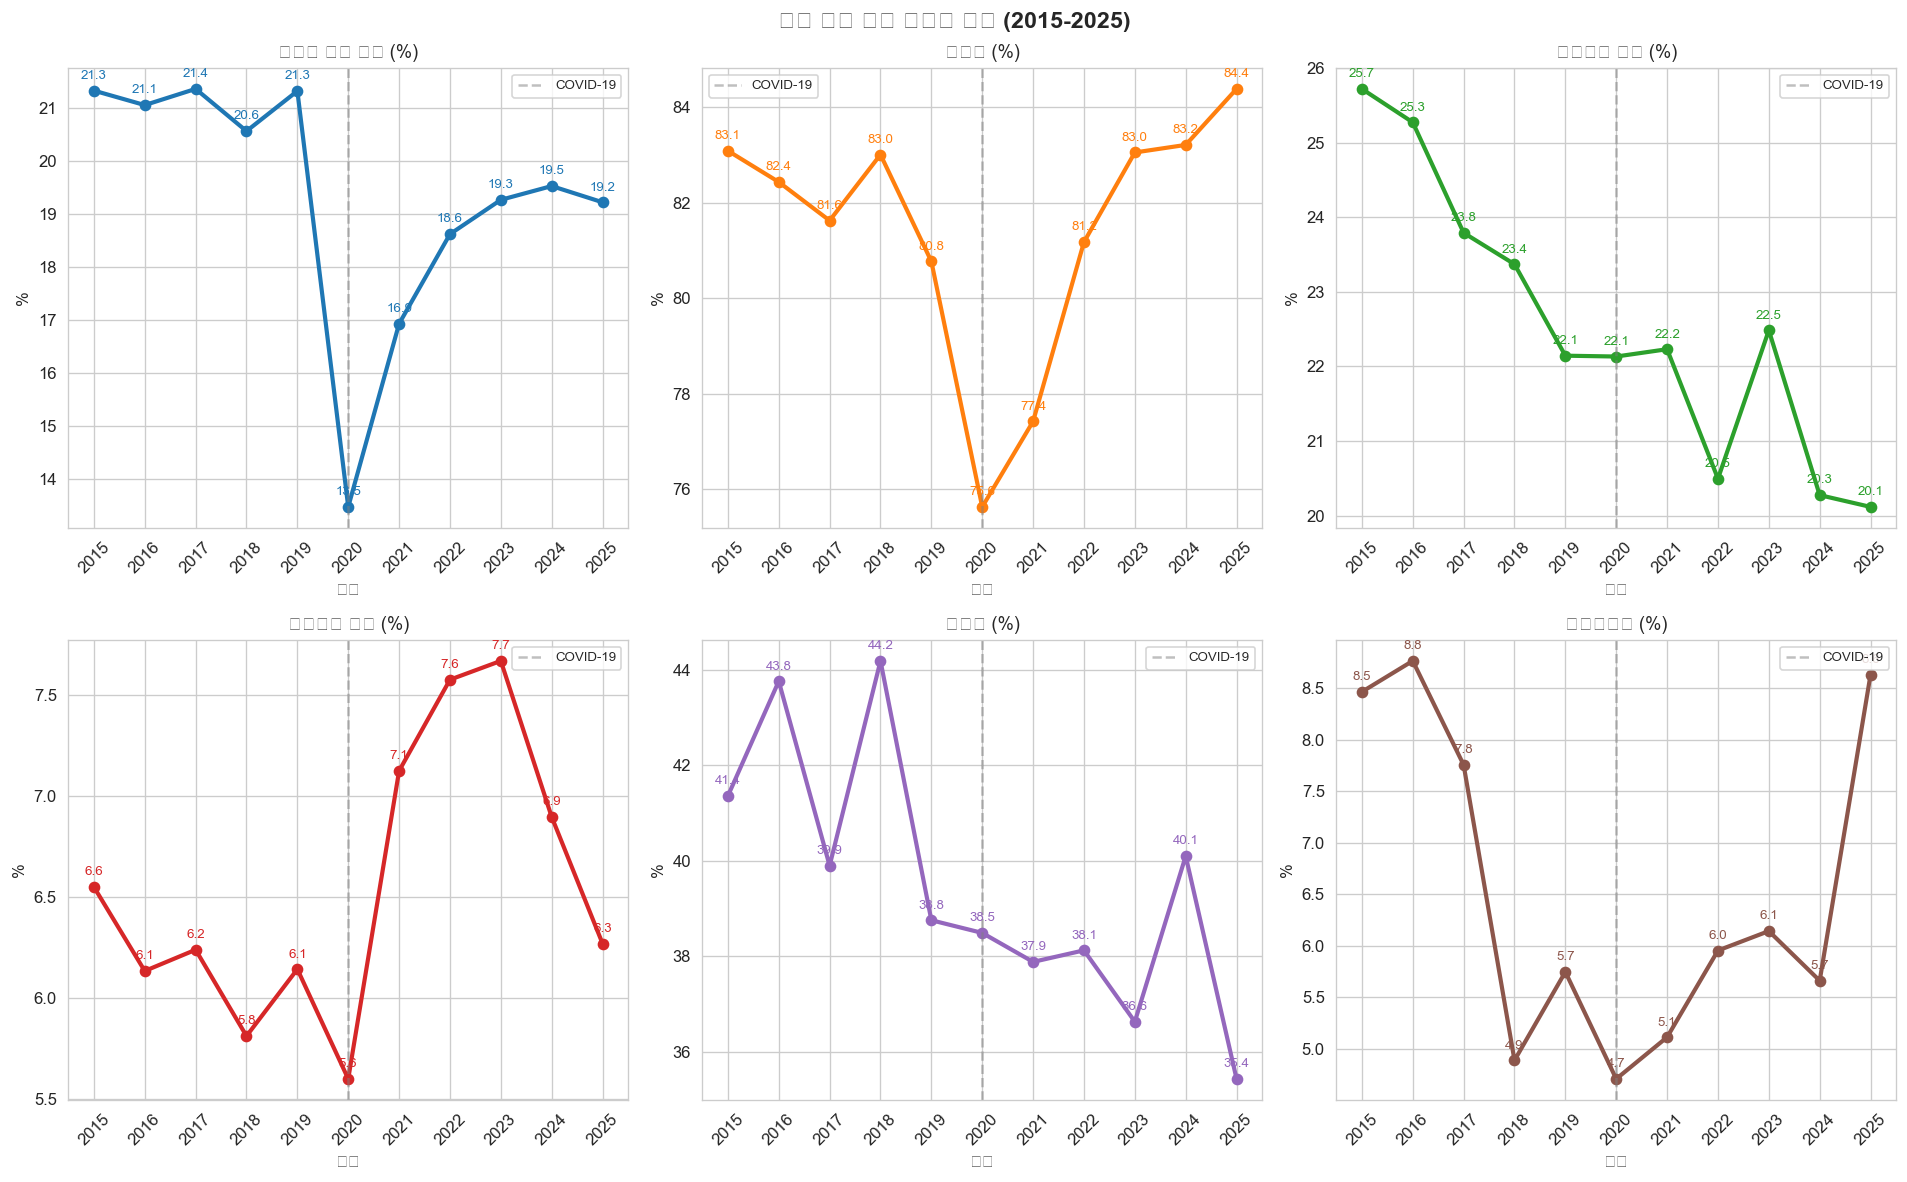

In [6]:
trend_vars = {
    '건강나쁨': '주관적 건강 나쁨 (%)',
    '음주': '음주율 (%)',
    '스트레스_많음': '스트레스 많음 (%)',
    '우울증상': '우울증상 경험 (%)',
    '비만': '비만율 (%)',
    '미충족의료': '미충족의료 (%)',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = sns.color_palette('tab10', 6)

for ax, (col, title), color in zip(axes.flatten(), trend_vars.items(), colors):
    trend = df_all.groupby('year')[col].mean().mul(100)
    ax.plot(trend.index, trend.values, marker='o', color=color, linewidth=2.5, markersize=6)
    # 변화량 주석
    for x, y in zip(trend.index, trend.values):
        ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                    xytext=(0, 7), ha='center', fontsize=8, color=color)
    # 2020 코로나 기준선
    ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5, label='COVID-19')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('연도')
    ax.set_ylabel('%')
    ax.set_xticks(trend.index)
    ax.set_xticklabels(trend.index, rotation=45)
    ax.legend(fontsize=8)

plt.suptitle('주요 건강 지표 연도별 추이 (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


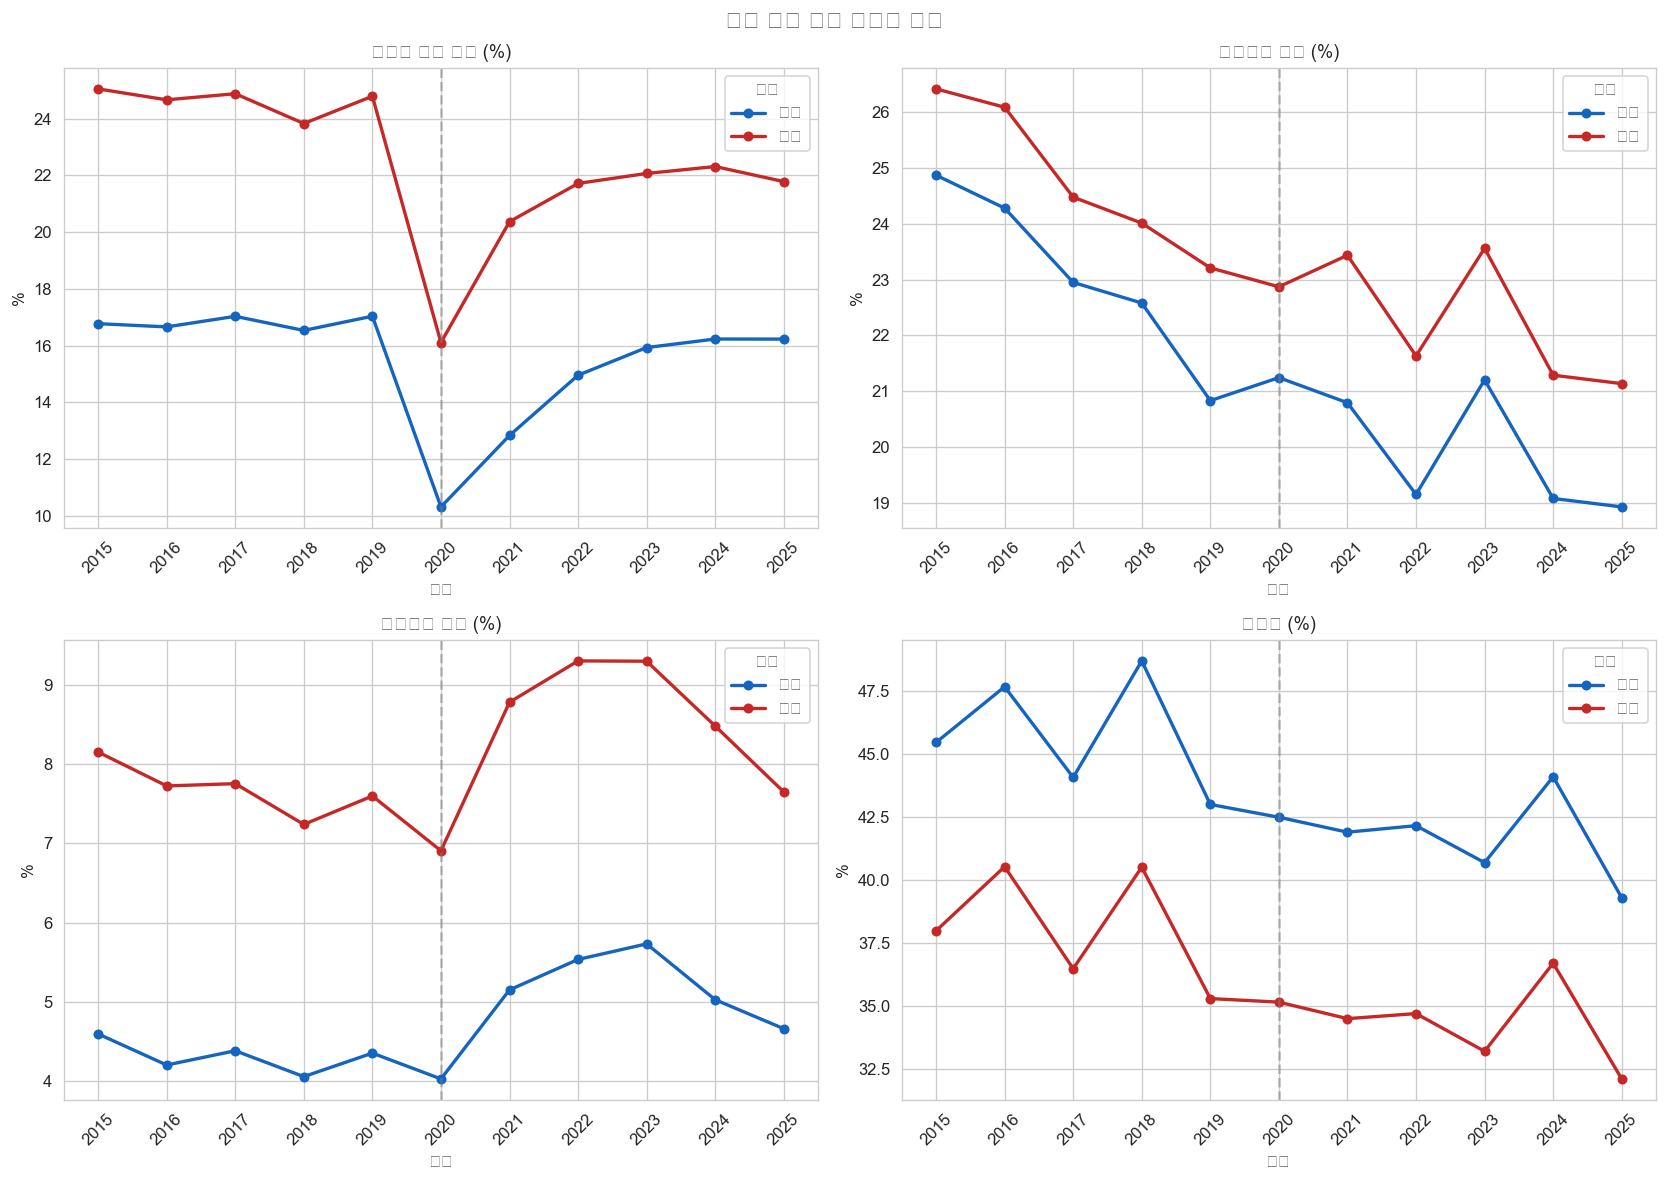

In [7]:
# 성별 × 연도 주요 지표
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_cols = ['건강나쁨', '스트레스_많음', '우울증상', '비만']
titles = ['주관적 건강 나쁨 (%)', '스트레스 많음 (%)', '우울증상 경험 (%)', '비만율 (%)']
colors_g = {'남성': '#1565C0', '여성': '#C62828'}

for ax, col, title in zip(axes.flatten(), plot_cols, titles):
    for gender, grp in df_all.groupby('성별'):
        trend = grp.groupby('year')[col].mean().mul(100)
        ax.plot(trend.index, trend.values, marker='o', label=gender,
                linewidth=2, color=colors_g[gender], markersize=5)
    ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('연도')
    ax.set_ylabel('%')
    ax.set_xticks(sorted(df_all['year'].unique()))
    ax.set_xticklabels(sorted(df_all['year'].unique()), rotation=45)
    ax.legend(title='성별')

plt.suptitle('성별 건강 지표 연도별 추이', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. 나이별 건강 패턴

나이 그룹(19-29세 ~ 70세이상)에 따른 건강 지표를 분석합니다.

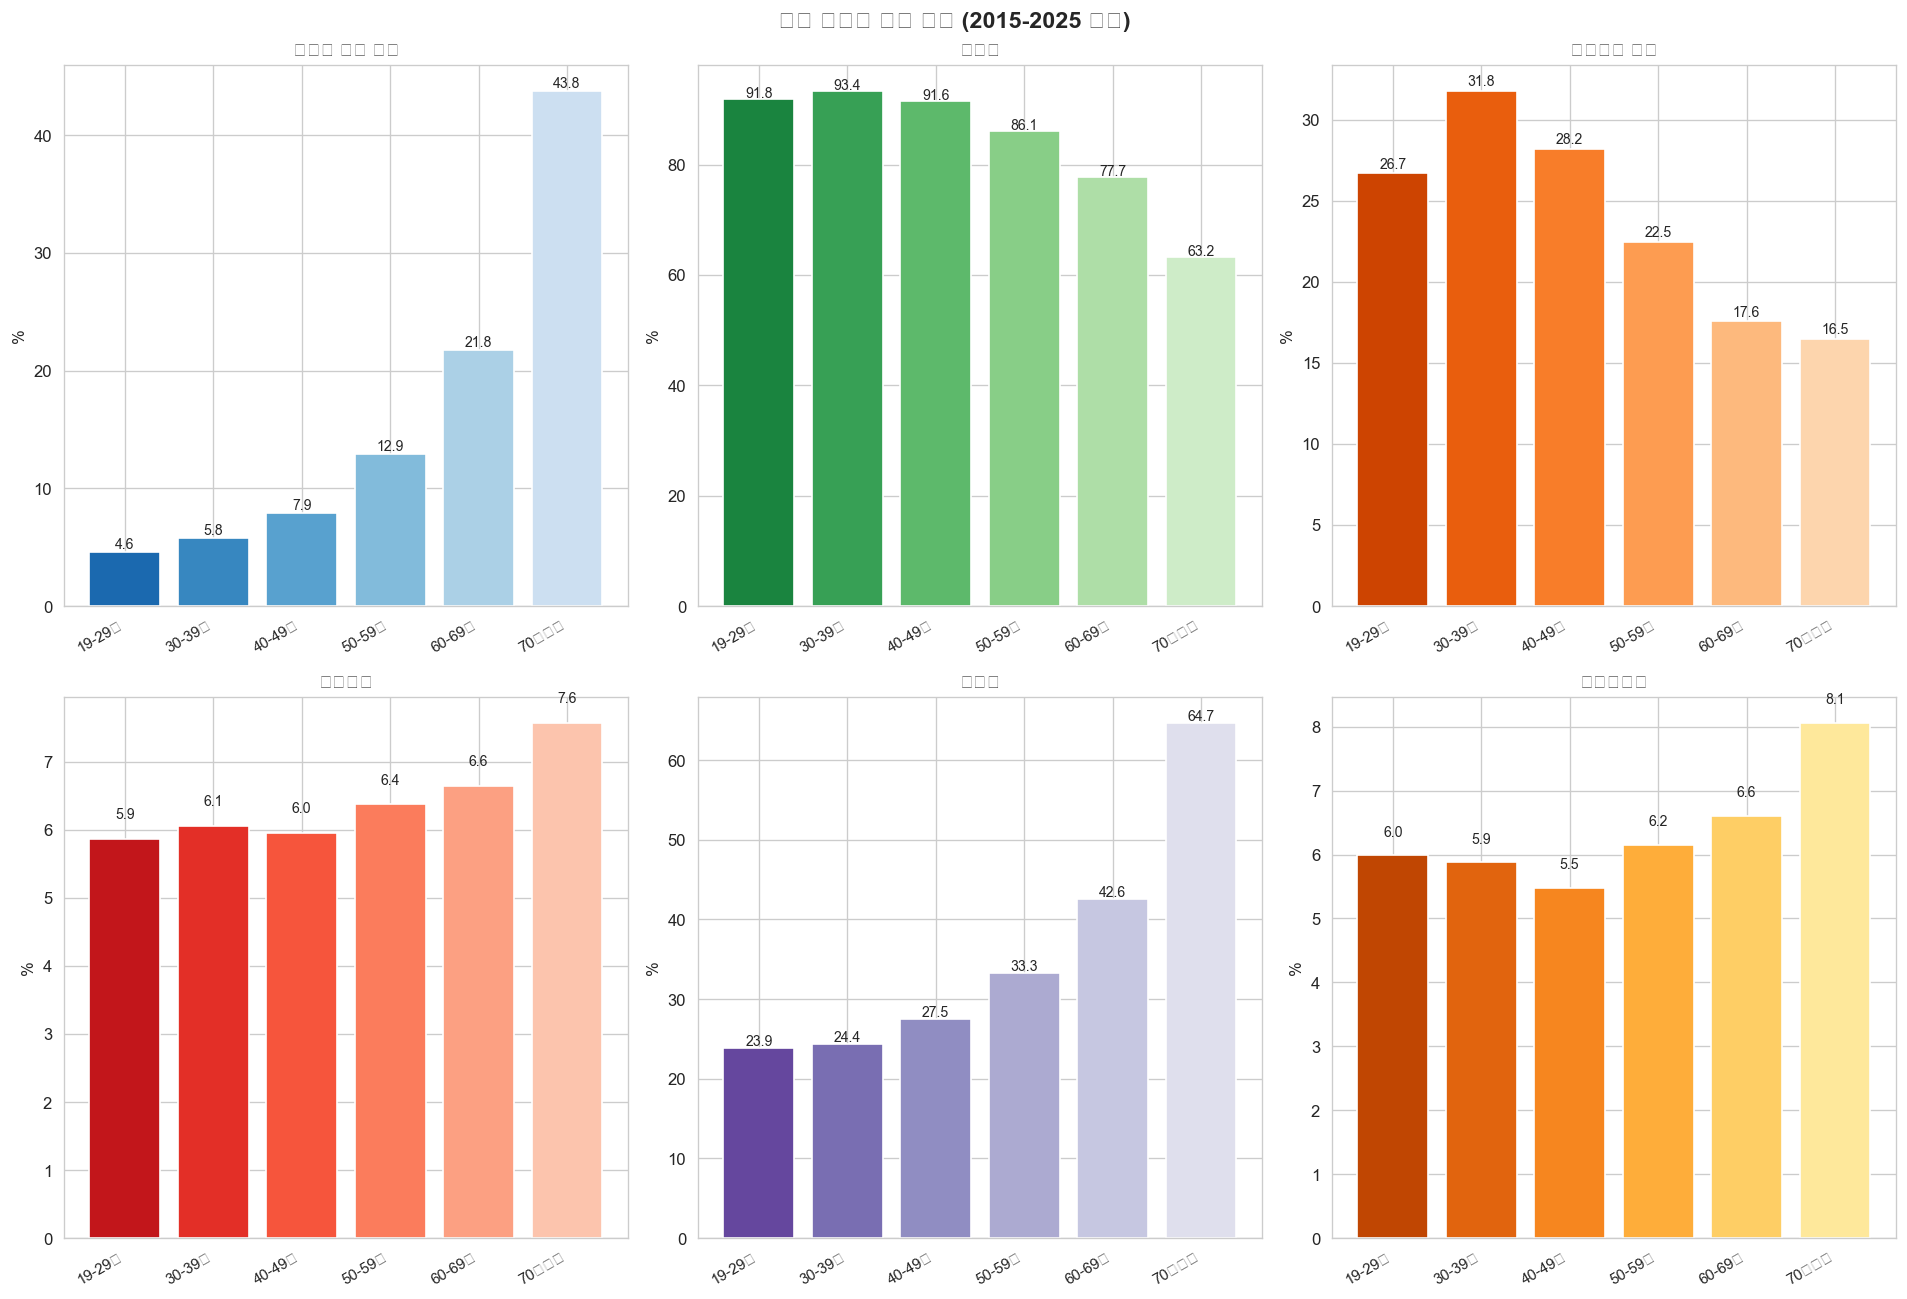

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
age_plot_cols = ['건강나쁨', '음주', '스트레스_많음', '우울증상', '비만', '미충족의료']
age_titles   = ['주관적 건강 나쁨', '음주율', '스트레스 많음', '우울증상', '비만율', '미충족의료']
palettes = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'YlOrBr']

for ax, col, title, pal in zip(axes.flatten(), age_plot_cols, age_titles, palettes):
    stats = df_all.groupby('age_group', observed=True)[col].mean().mul(100).dropna()
    bars = ax.bar(range(len(stats)), stats.values,
                  color=sns.color_palette(pal+'_r', len(stats)+2)[1:-1])
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('%')
    for bar, val in zip(bars, stats.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', fontsize=8.5)

plt.suptitle('나이 그룹별 건강 지표 (2015-2025 전체)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


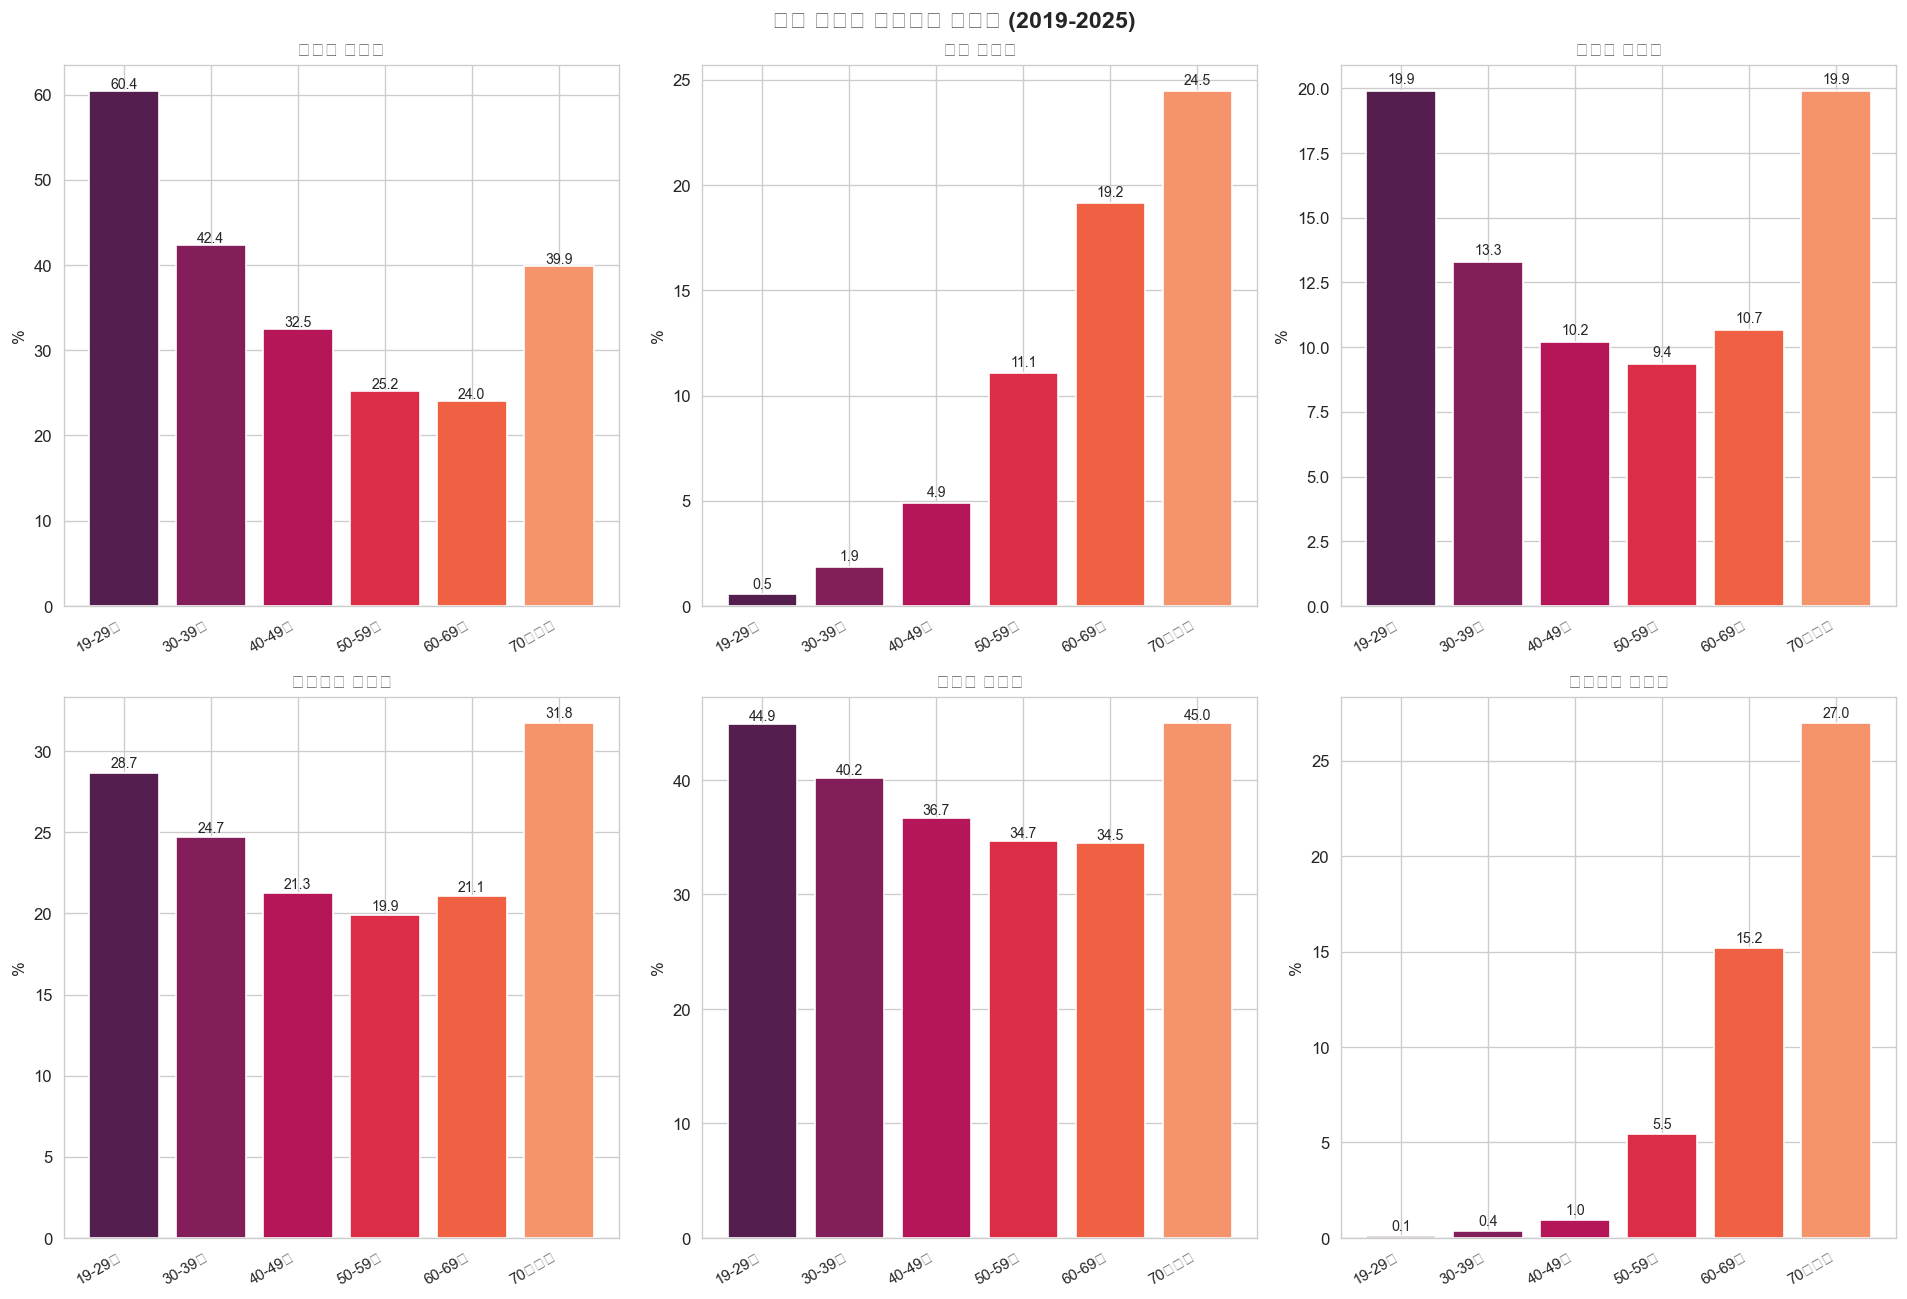

In [9]:
# 2019+ 나이별 만성질환
chronic_cols  = ['고혈압', '당뇨', '뇌졸중', '심근경색', '관절염', '골다공증']
chronic_title = ['고혈압 유병률', '당뇨 유병률', '뇌졸중 유병률', '심근경색 유병률', '관절염 유병률', '골다공증 유병률']
avail = [(c, t) for c, t in zip(chronic_cols, chronic_title) if c in df_new.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
for ax, (col, title) in zip(axes.flatten(), avail):
    stats = df_new.groupby('age_group', observed=True)[col].mean().mul(100).dropna()
    bars = ax.bar(range(len(stats)), stats.values,
                  color=sns.color_palette('rocket', len(stats)+2)[1:-1])
    ax.set_xticks(range(len(stats)))
    ax.set_xticklabels(stats.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('%')
    for bar, val in zip(bars, stats.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{val:.1f}', ha='center', fontsize=8.5)

# 빈 축 숨기기
for ax in axes.flatten()[len(avail):]:
    ax.set_visible(False)

plt.suptitle('나이 그룹별 만성질환 유병률 (2019-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


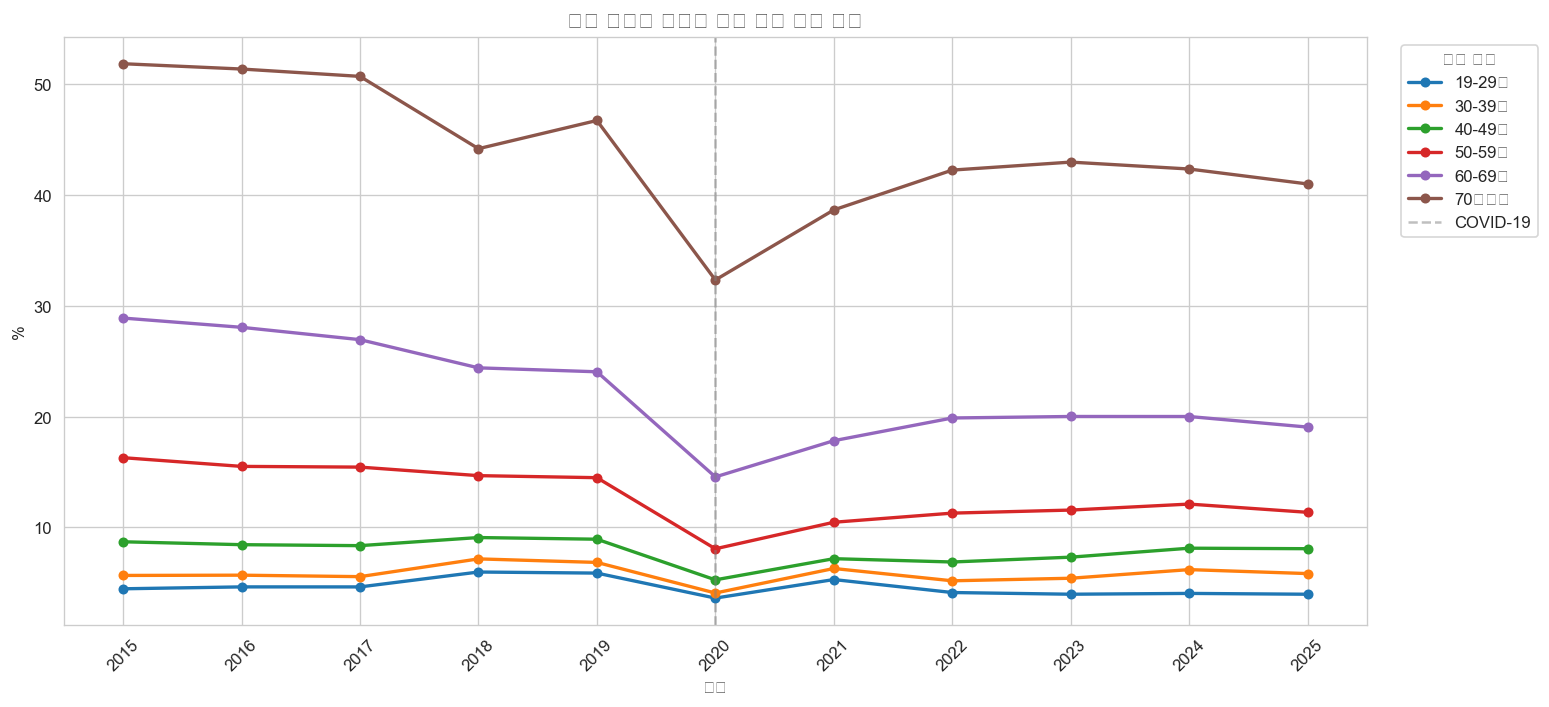

In [10]:
# 나이 × 연도 트렌드 (주관적 건강 나쁨)
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', 6)
for label, (grp, color) in zip(age_labels,
    zip(df_all.groupby('age_group', observed=True), palette)):
    name, sub = grp
    trend = sub.groupby('year')['건강나쁨'].mean().mul(100)
    ax.plot(trend.index, trend.values, marker='o', label=name, color=color,
            linewidth=2, markersize=5)

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5, label='COVID-19')
ax.set_title('나이 그룹별 주관적 건강 나쁨 연도 추이', fontsize=13)
ax.set_xlabel('연도')
ax.set_ylabel('%')
ax.set_xticks(sorted(df_all['year'].unique()))
ax.set_xticklabels(sorted(df_all['year'].unique()), rotation=45)
ax.legend(title='나이 그룹', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 7. 지역별 건강 격차

**주의**: 2015-2018년 알파벳 지역코드(A-Q)를 숫자코드로 변환할 때 순서가 다를 수 있으므로,
지역별 분석은 코드가 명확한 **2019-2025** 데이터를 기준으로 합니다.

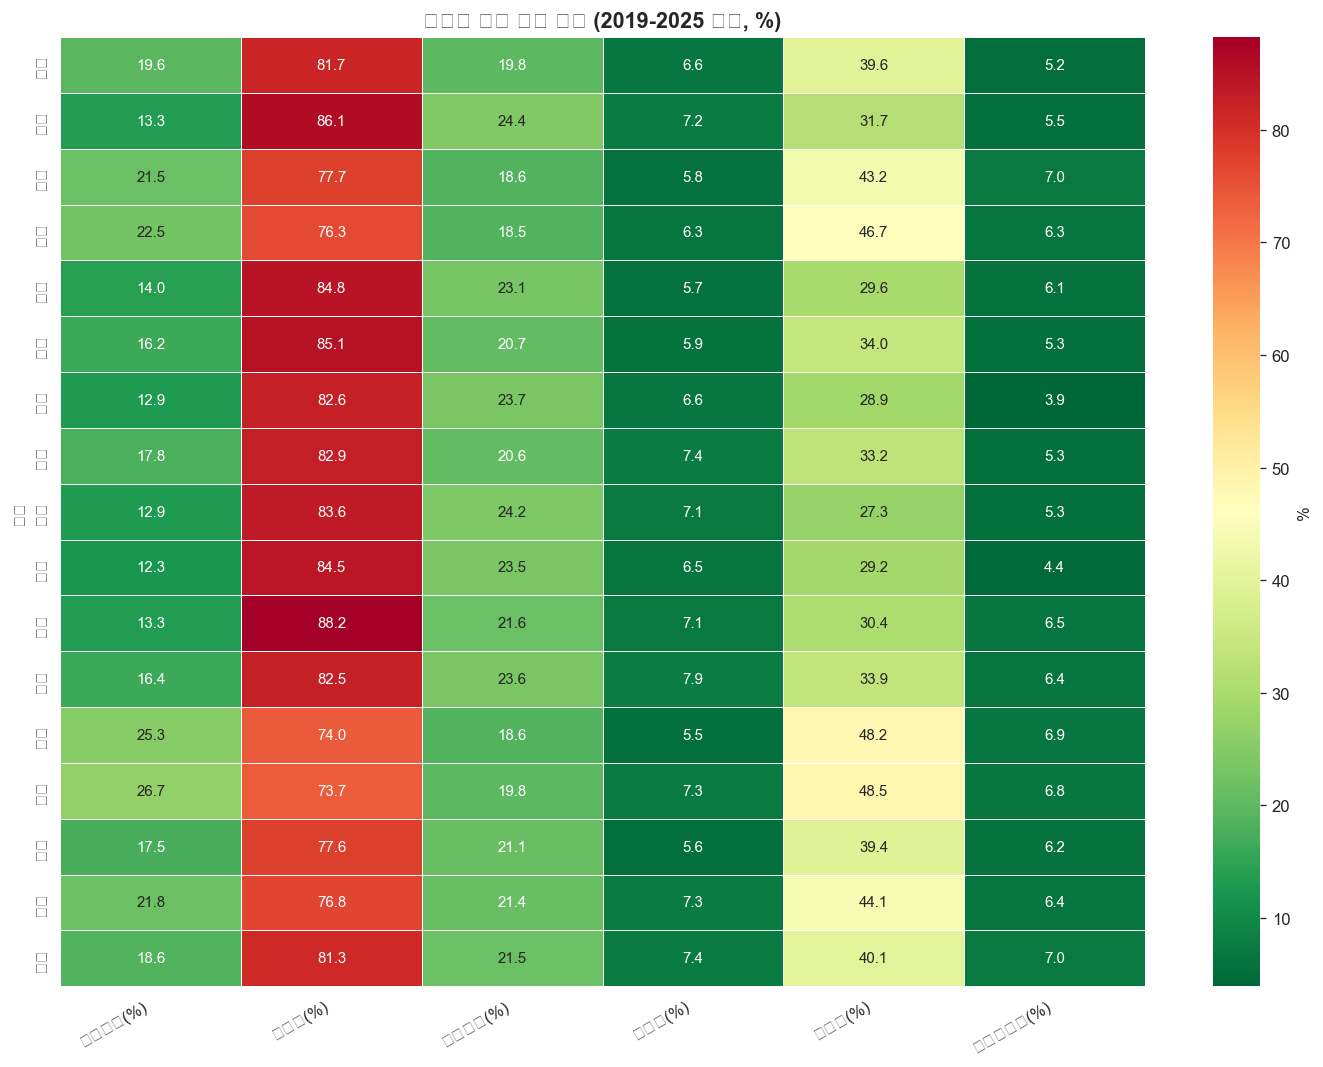

In [11]:
# 지역별 건강 지표 히트맵
region_health = ['건강나쁨', '음주', '스트레스_많음', '우울증상', '비만', '미충족의료']
region_titles = ['건강나쁨(%)', '음주율(%)', '스트레스(%)', '우울증(%)', '비만율(%)', '미충족의료(%)']

r_stats = df_new.groupby('지역')[region_health].mean().mul(100).dropna(how='all')
r_stats = r_stats.reindex(sorted(r_stats.index))  # 가나다 정렬

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(r_stats, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, cbar_kws={'label':'%'},
            annot_kws={'size': 9})
ax.set_title('지역별 주요 건강 지표 (2019-2025 평균, %)', fontsize=13, fontweight='bold')
ax.set_xticklabels(region_titles, rotation=30, ha='right')
plt.tight_layout()
plt.show()


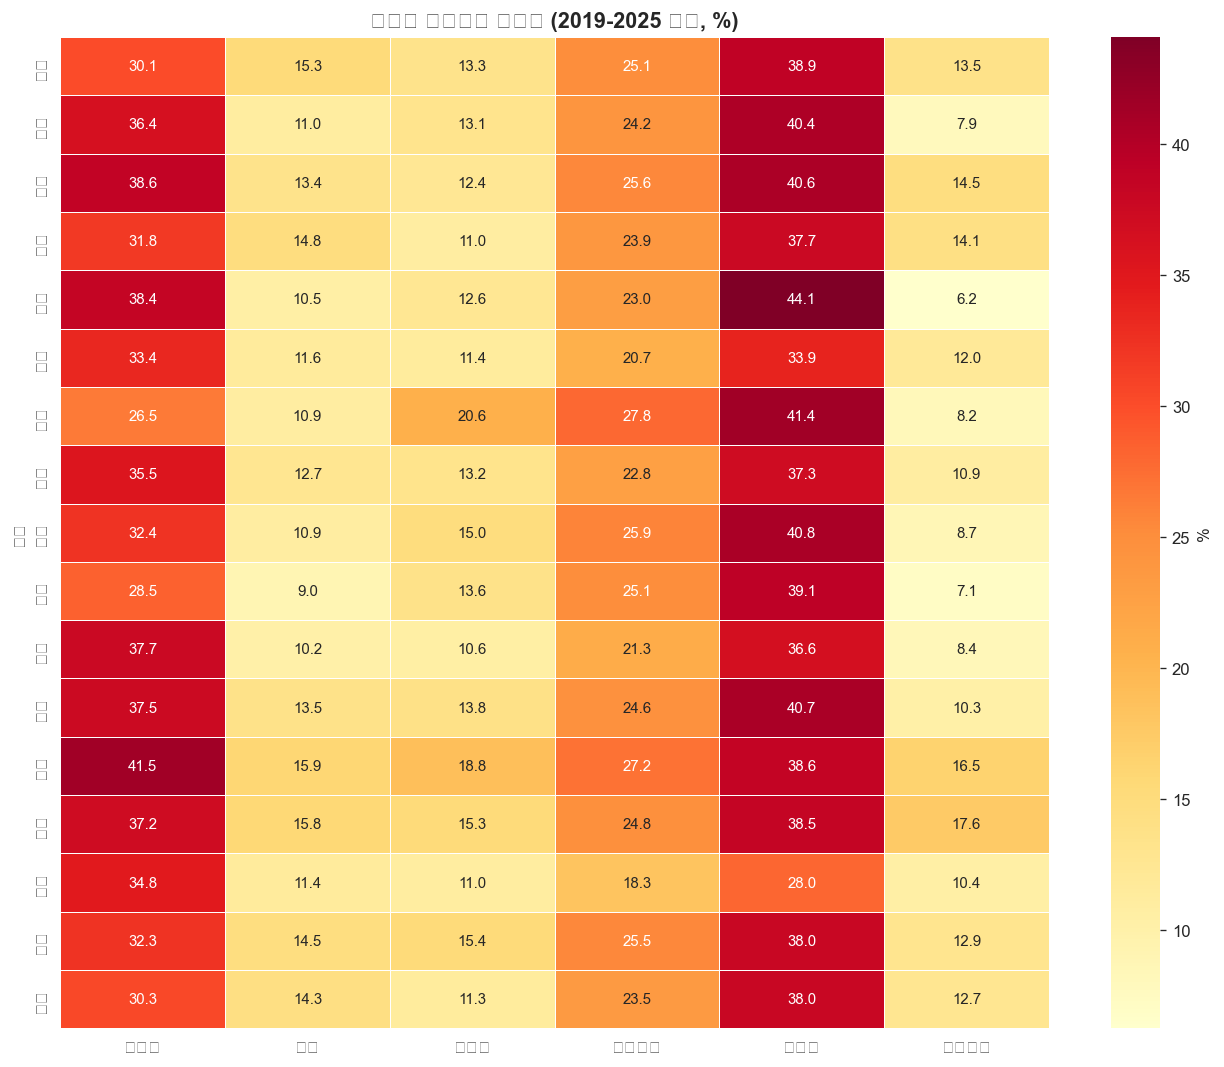

In [12]:
# 지역별 만성질환 히트맵
chronic_map_cols = [c for c in ['고혈압','당뇨','뇌졸중','심근경색','관절염','골다공증'] 
                    if c in df_new.columns]
r_chronic = df_new.groupby('지역')[chronic_map_cols].mean().mul(100).dropna(how='all')
r_chronic = r_chronic.reindex(sorted(r_chronic.index))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(r_chronic, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label':'%'},
            annot_kws={'size': 9})
ax.set_title('지역별 만성질환 유병률 (2019-2025 평균, %)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


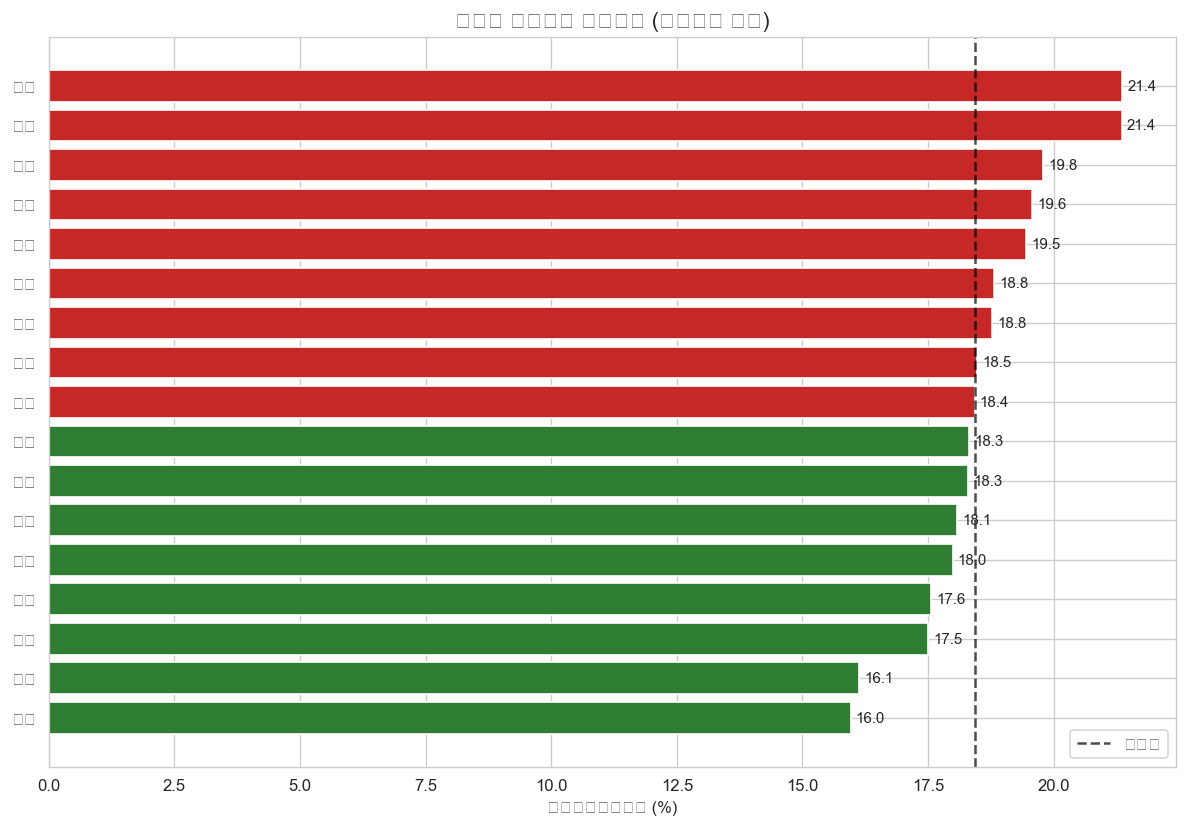

In [13]:
# 지역별 건강 종합 순위 (건강나쁨 + 고혈압 + 당뇨 + 스트레스 높을수록 나쁨)
score_cols = [c for c in ['건강나쁨', '고혈압', '당뇨', '스트레스_많음', '우울증상']
              if c in df_new.columns]
r_all = df_new.groupby('지역')[score_cols].mean().mul(100).dropna(how='all')
r_all['종합건강위험지수'] = r_all[score_cols].mean(axis=1)
r_sorted = r_all['종합건강위험지수'].sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#2E7D32' if v < r_sorted.median() else '#C62828' for v in r_sorted.values]
bars = ax.barh(range(len(r_sorted)), r_sorted.values, color=colors_bar)
ax.set_yticks(range(len(r_sorted)))
ax.set_yticklabels(r_sorted.index)
ax.axvline(r_sorted.median(), color='black', linestyle='--', alpha=0.7, label='중앙값')
for i, (bar, val) in enumerate(zip(bars, r_sorted.values)):
    ax.text(val+0.1, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
ax.set_title('지역별 건강위험 종합지수 (낮을수록 건강)', fontsize=13)
ax.set_xlabel('종합건강위험지수 (%)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. 성별 건강 차이

남녀별 건강 지표를 비교하고, 나이 × 성별 상호작용을 분석합니다.

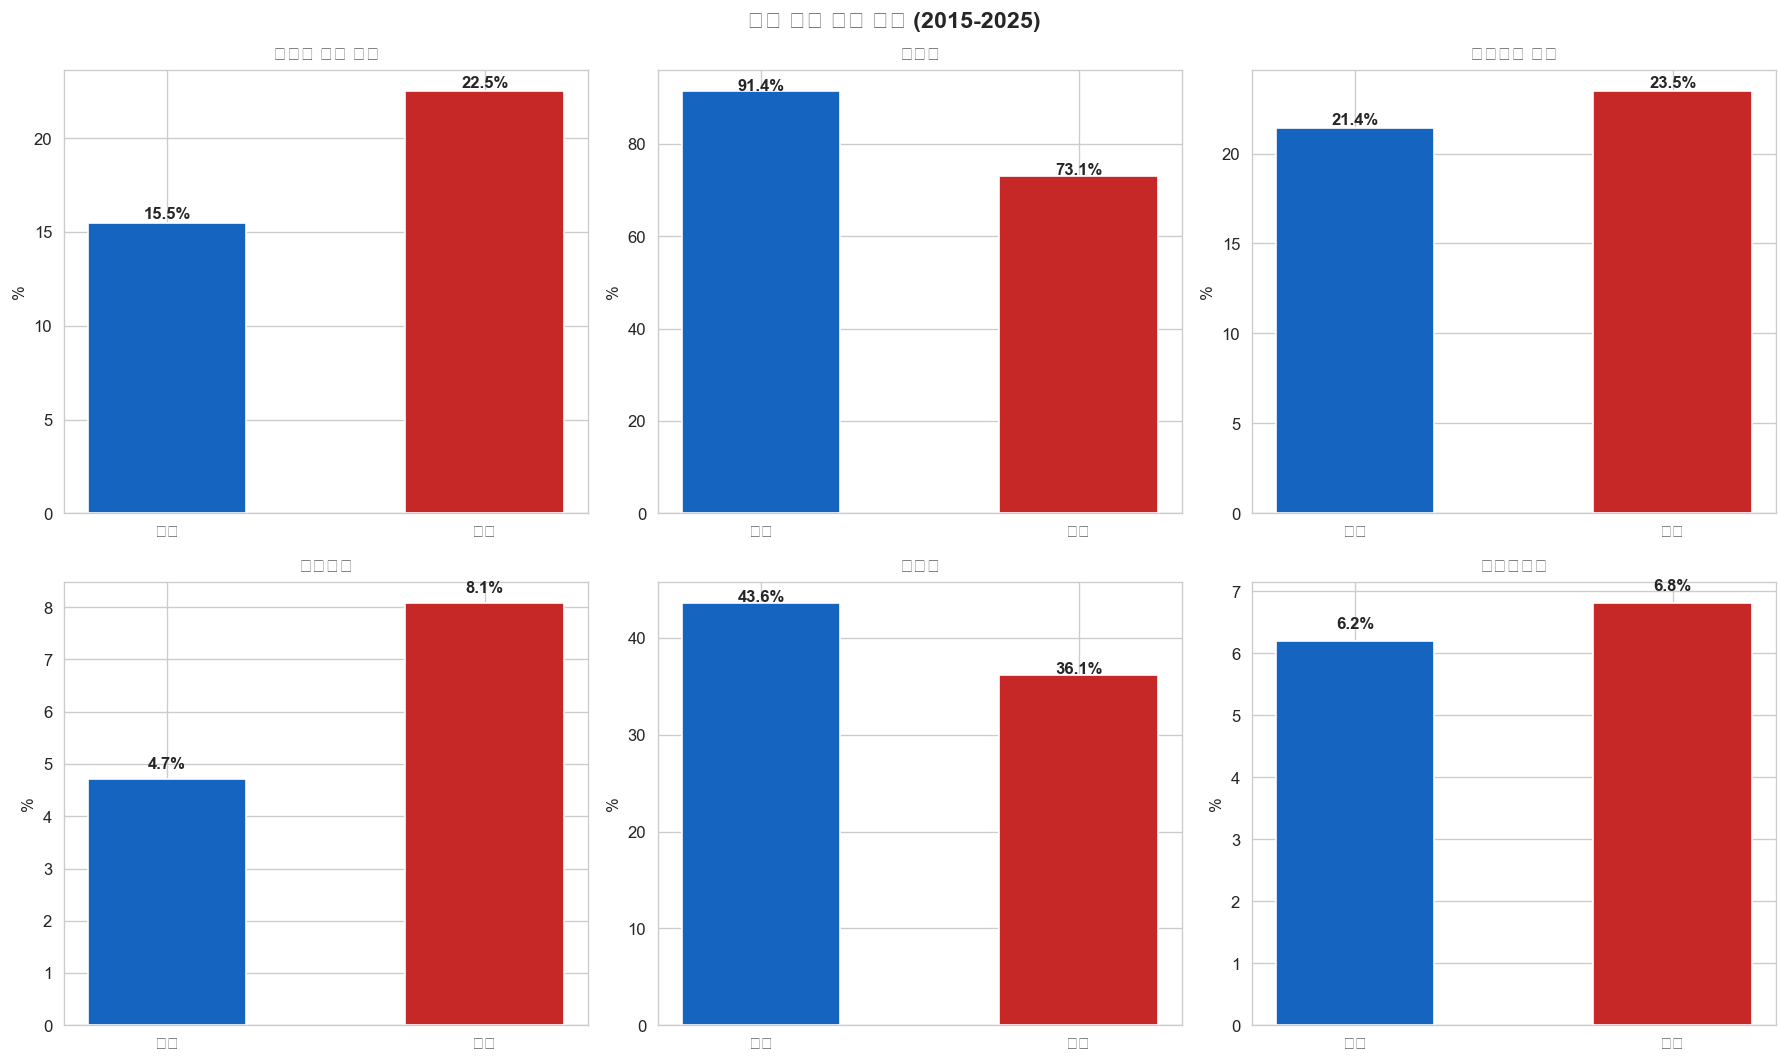

In [14]:
# 성별 × 건강 지표 전체 비교 (막대)
g_plot_cols = ['건강나쁨', '음주', '스트레스_많음', '우울증상', '비만', '미충족의료']
g_titles    = ['주관적 건강 나쁨', '음주율', '스트레스 많음', '우울증상', '비만율', '미충족의료']

g_stats = df_all.groupby('성별')[g_plot_cols].mean().mul(100)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
x = np.arange(2)
colors_gd = ['#1565C0', '#C62828']

for ax, col, title in zip(axes.flatten(), g_plot_cols, g_titles):
    vals = [g_stats.loc['남성', col], g_stats.loc['여성', col]]
    bars = ax.bar(['남성','여성'], vals, color=colors_gd, width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('%')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('성별 건강 지표 비교 (2015-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


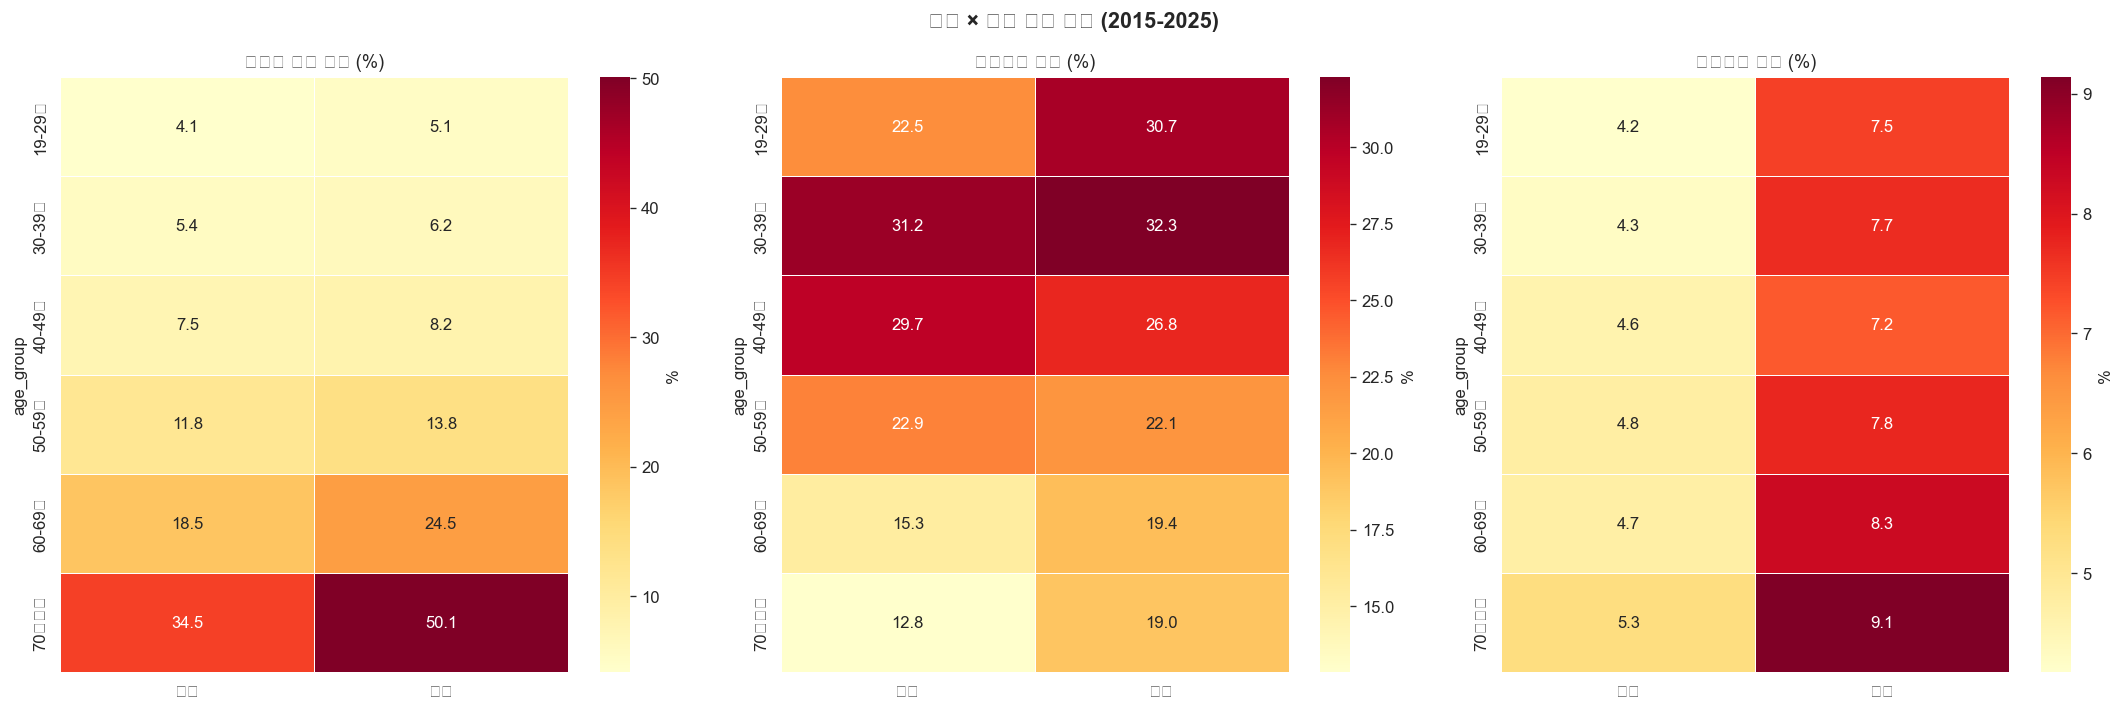

In [15]:
# 성별 × 나이 그룹 상호작용 히트맵
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
interaction_cols = ['건강나쁨', '스트레스_많음', '우울증상']
int_titles       = ['주관적 건강 나쁨 (%)', '스트레스 많음 (%)', '우울증상 경험 (%)']

for ax, col, title in zip(axes, interaction_cols, int_titles):
    pivot = df_all.groupby(['age_group','성별'], observed=True)[col].mean().unstack().mul(100)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
                linewidths=0.5, cbar_kws={'label':'%'}, annot_kws={'size':10})
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')

plt.suptitle('나이 × 성별 건강 지표 (2015-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


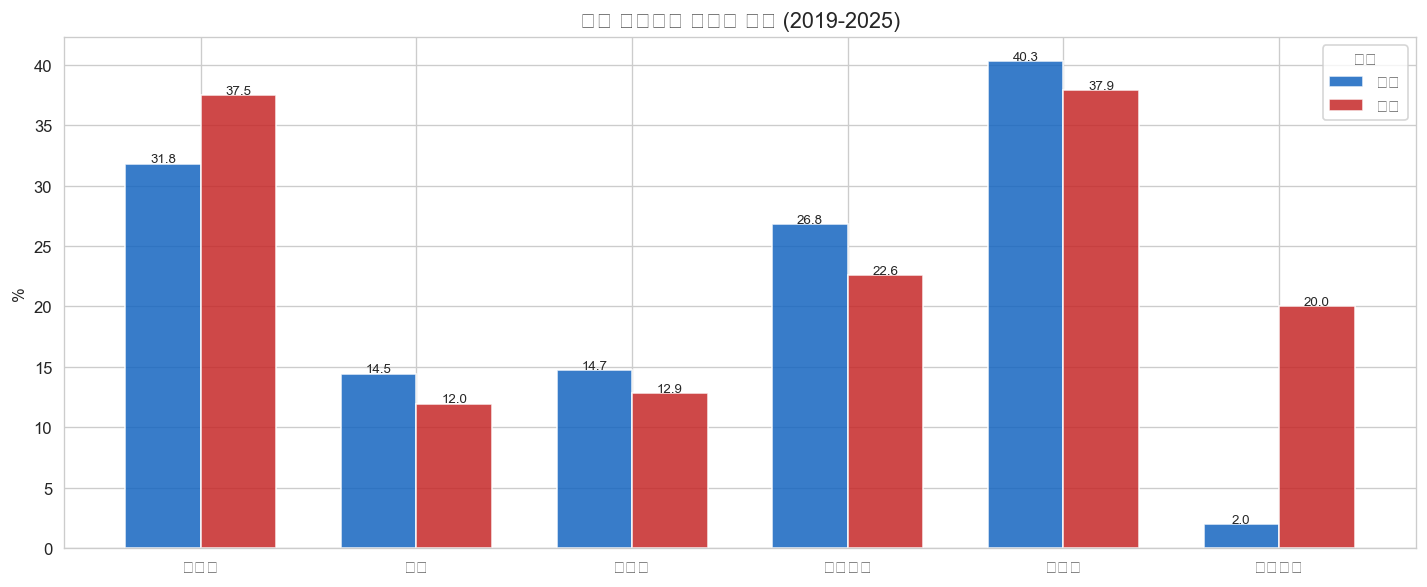

In [16]:
# 2019+ 성별 × 만성질환
chronic_gender = [c for c in ['고혈압','당뇨','뇌졸중','심근경색','관절염','골다공증']
                  if c in df_new.columns]
g2_stats = df_new.groupby('성별')[chronic_gender].mean().mul(100)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(chronic_gender))
w = 0.35
bars1 = ax.bar(x - w/2, g2_stats.loc['남성', chronic_gender].values,
               w, label='남성', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + w/2, g2_stats.loc['여성', chronic_gender].values,
               w, label='여성', color='#C62828', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(chronic_gender, fontsize=10)
ax.set_ylabel('%')
ax.set_title('성별 만성질환 유병률 비교 (2019-2025)', fontsize=13)
ax.legend(title='성별')
for bar in list(bars1)+list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{bar.get_height():.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


## 9. 건강행동 × 건강결과

흡연, 음주, 걷기 실천이 건강 결과에 미치는 영향을 분석합니다.

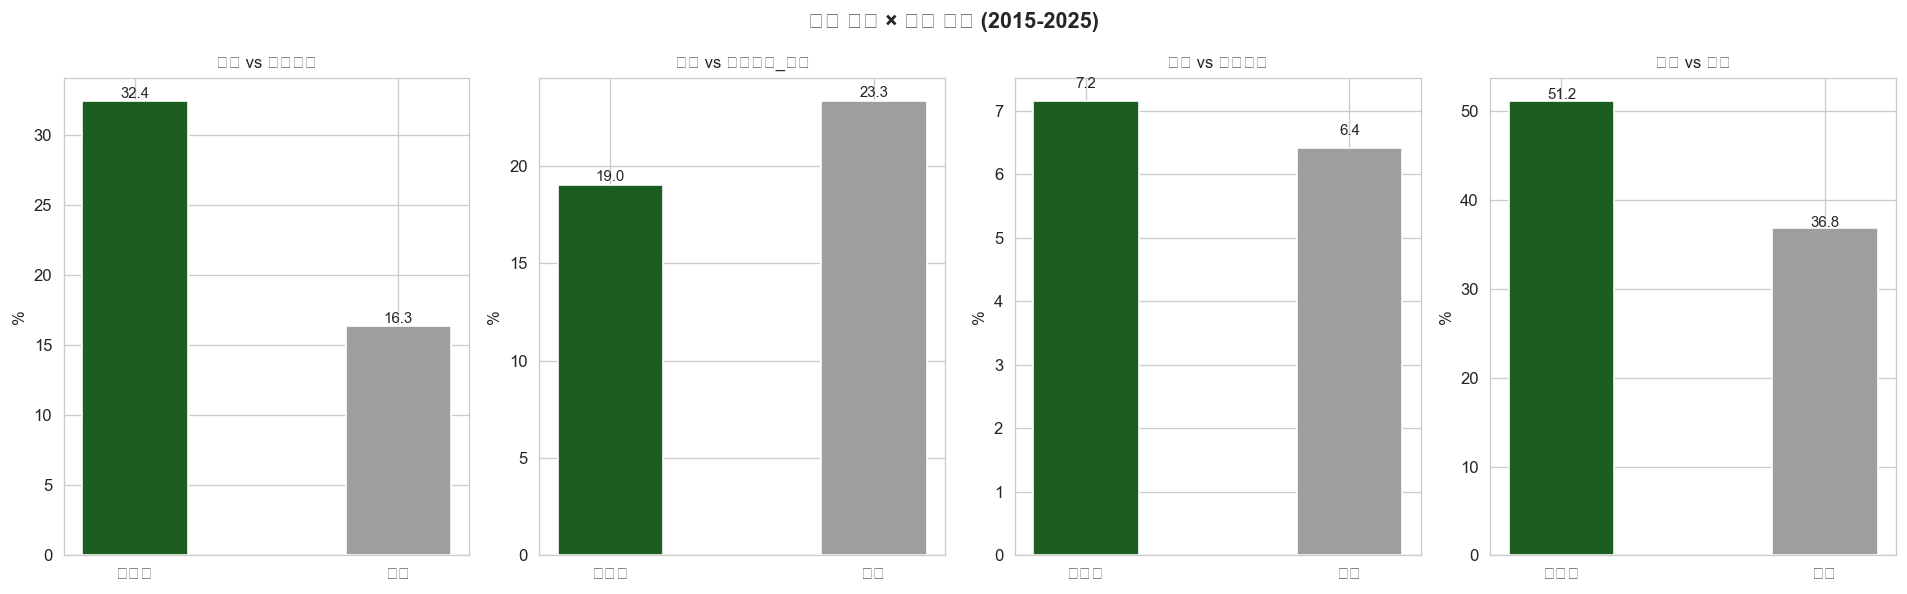

In [17]:
# ── 음주 × 건강 지표 (전체 연도) ──
outcome_cols = ['건강나쁨', '스트레스_많음', '우울증상', '비만']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, outcome_cols):
    stats = df_all.groupby('음주')[col].mean().mul(100)
    labels = {1.0: '음주', 0.0: '비음주'}
    x_labels = [labels.get(k, str(k)) for k in stats.index]
    bars = ax.bar(x_labels, stats.values, color=['#1B5E20','#9E9E9E'], width=0.4)
    ax.set_title(f'음주 vs {col}', fontsize=10)
    ax.set_ylabel('%')
    for bar, val in zip(bars, stats.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('음주 여부 × 건강 지표 (2015-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


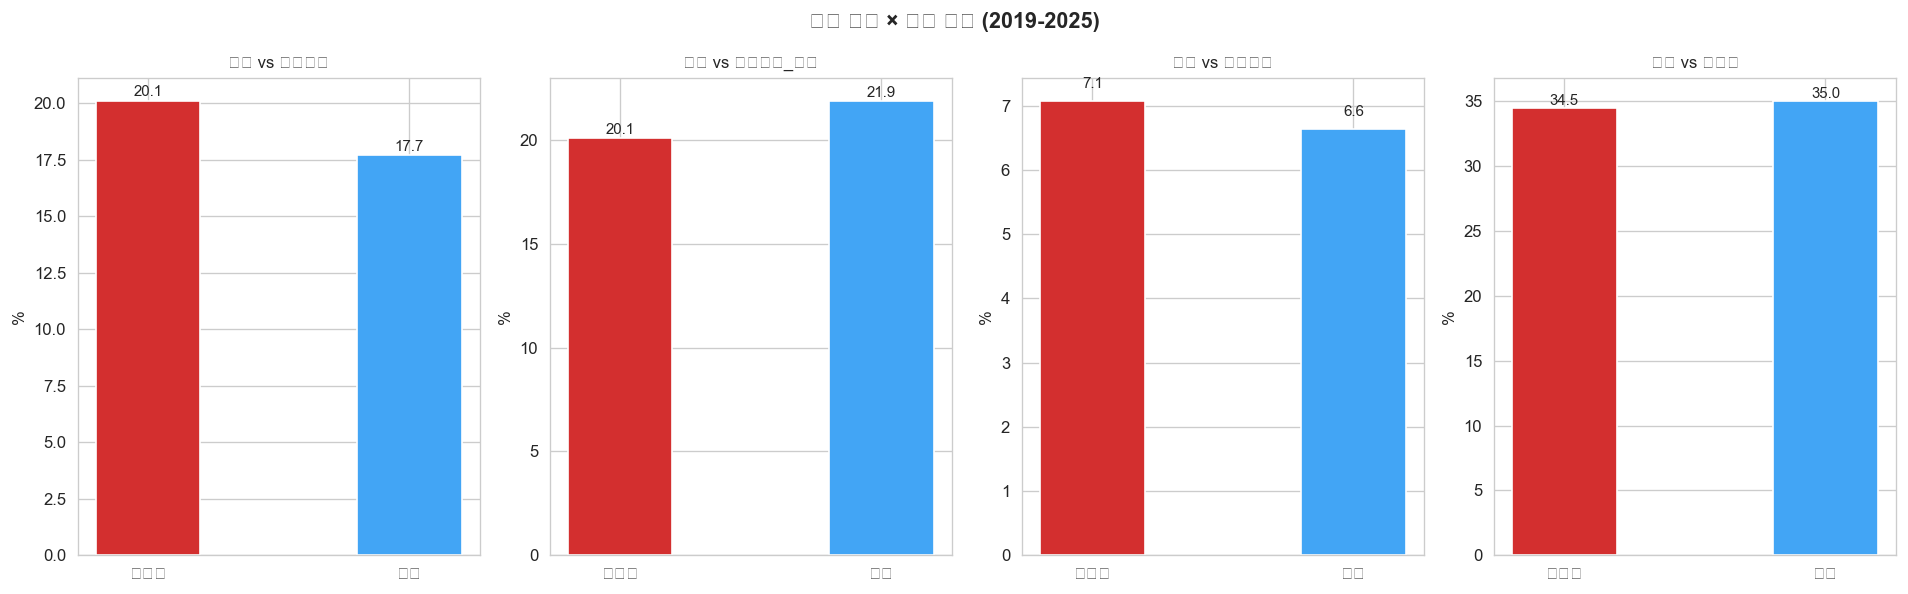

In [18]:
# ── 흡연 × 건강 지표 (2019-2025) ──
if '흡연' in df_new.columns:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    outcome_new = ['건강나쁨', '스트레스_많음', '우울증상', '고혈압']
    avail_out = [(c, ax) for c, ax in zip(outcome_new, axes) if c in df_new.columns]
    for col, ax in avail_out:
        stats = df_new.groupby('흡연')[col].mean().mul(100).dropna()
        x_labels = {1.0: '흡연', 0.0: '비흡연'}
        bars = ax.bar([x_labels.get(k, str(k)) for k in stats.index],
                      stats.values, color=['#D32F2F','#42A5F5'], width=0.4)
        ax.set_title(f'흡연 vs {col}', fontsize=10)
        ax.set_ylabel('%')
        for bar, val in zip(bars, stats.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                    f'{val:.1f}', ha='center', fontsize=9)
    plt.suptitle('흡연 여부 × 건강 지표 (2019-2025)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


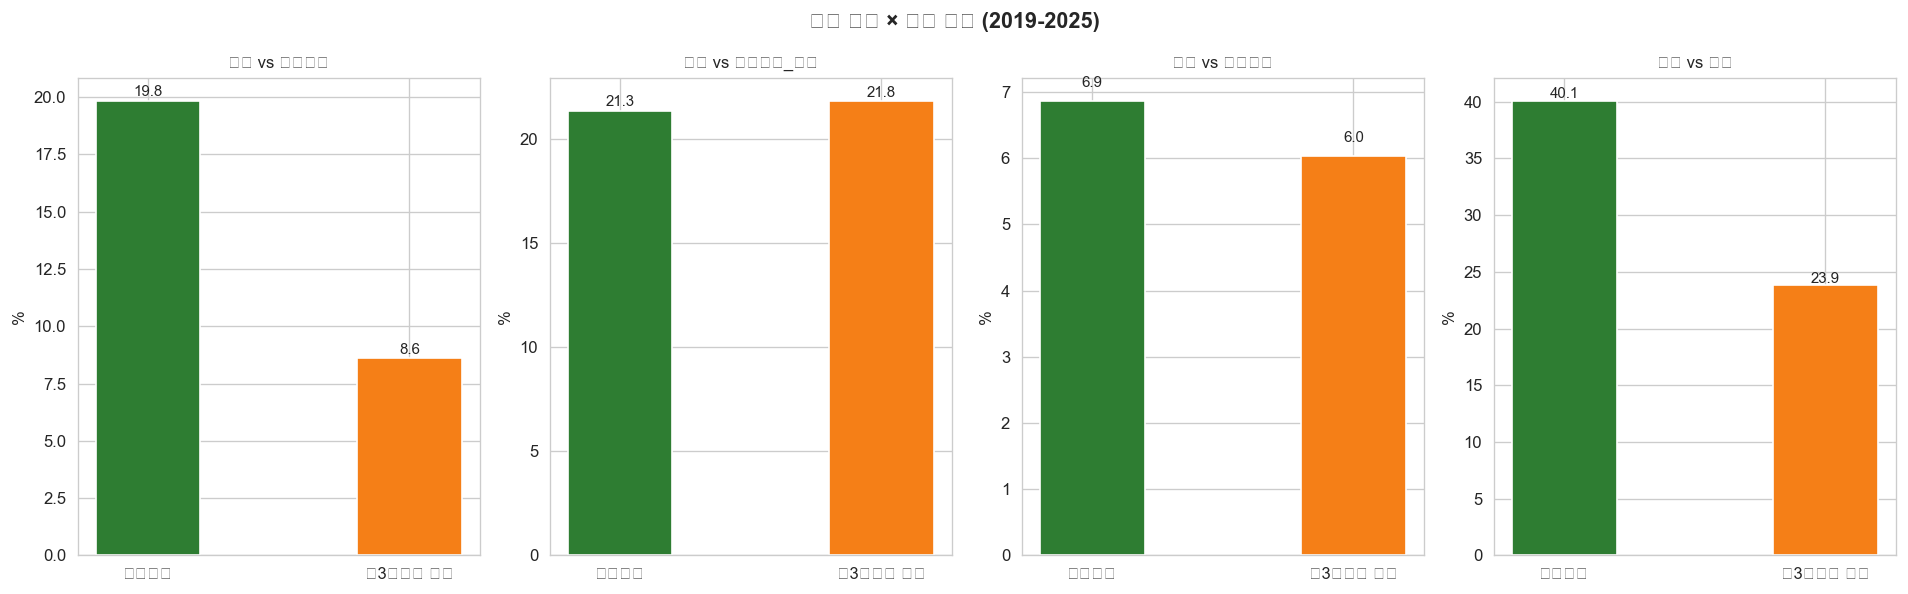

In [19]:
# ── 걷기 실천 × 건강 지표 (2019-2025) ──
if '걷기_주3일이상' in df_new.columns:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    walk_outcomes = ['건강나쁨', '스트레스_많음', '우울증상', '비만']
    for col, ax in zip(walk_outcomes, axes):
        if col not in df_new.columns:
            continue
        stats = df_new.groupby('걷기_주3일이상')[col].mean().mul(100).dropna()
        x_labels = {1.0: '주3일이상 걷기', 0.0: '걷기부족'}
        bars = ax.bar([x_labels.get(k, str(k)) for k in stats.index],
                      stats.values, color=['#2E7D32','#F57F17'], width=0.4)
        ax.set_title(f'걷기 vs {col}', fontsize=10)
        ax.set_ylabel('%')
        for bar, val in zip(bars, stats.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                    f'{val:.1f}', ha='center', fontsize=9)
    plt.suptitle('걷기 실천 × 건강 지표 (2019-2025)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


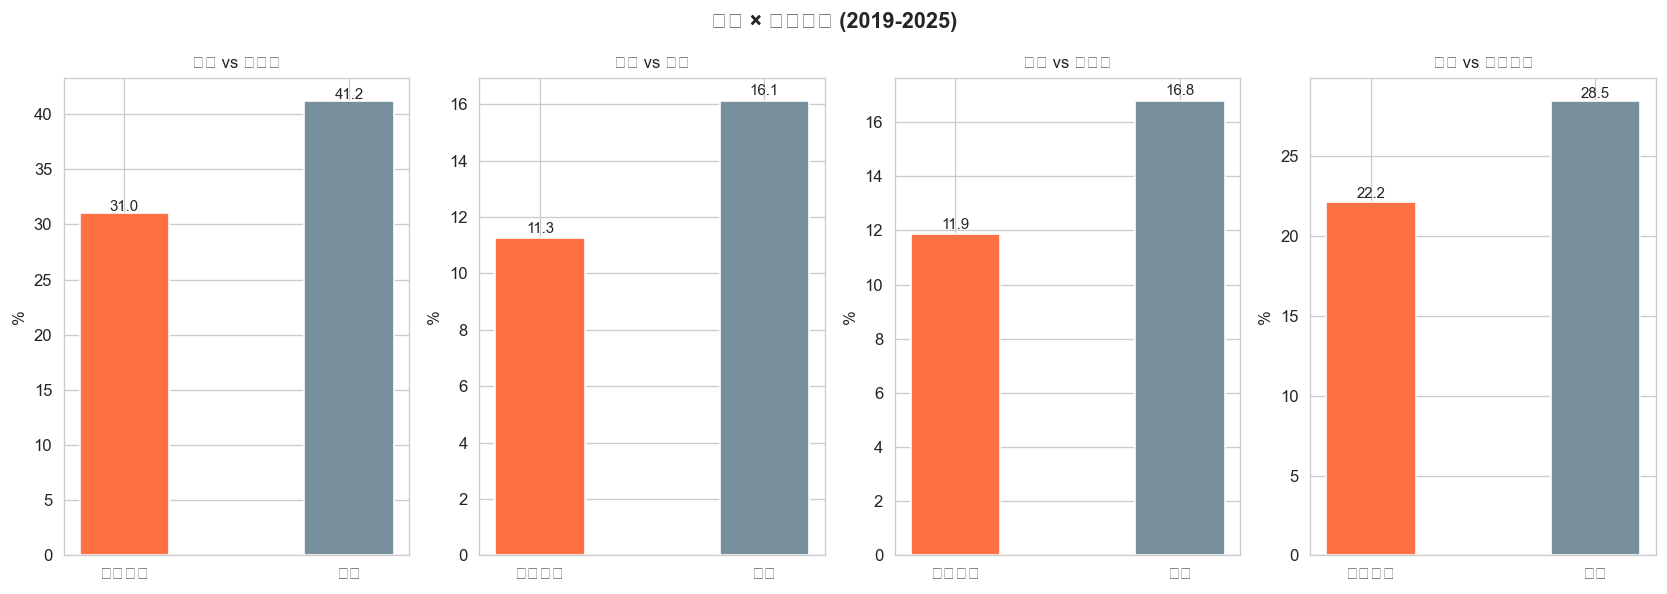

In [20]:
# ── 비만 × 만성질환 (2019-2025) ──
chronic_obesity = [c for c in ['고혈압', '당뇨', '뇌졸중', '심근경색'] if c in df_new.columns]
if chronic_obesity and '비만' in df_new.columns:
    fig, axes = plt.subplots(1, len(chronic_obesity), figsize=(14, 5))
    if len(chronic_obesity) == 1:
        axes = [axes]
    for col, ax in zip(chronic_obesity, axes):
        stats = df_new.groupby('비만')[col].mean().mul(100).dropna()
        x_labels = {1.0: '비만', 0.0: '비만아님'}
        bars = ax.bar([x_labels.get(k, str(k)) for k in stats.index],
                      stats.values, color=['#FF7043','#78909C'], width=0.4)
        ax.set_title(f'비만 vs {col}', fontsize=10)
        ax.set_ylabel('%')
        for bar, val in zip(bars, stats.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                    f'{val:.1f}', ha='center', fontsize=9)
    plt.suptitle('비만 × 만성질환 (2019-2025)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 10. 정신건강 심층 분석

스트레스·우울에 영향을 미치는 요인을 파악합니다.

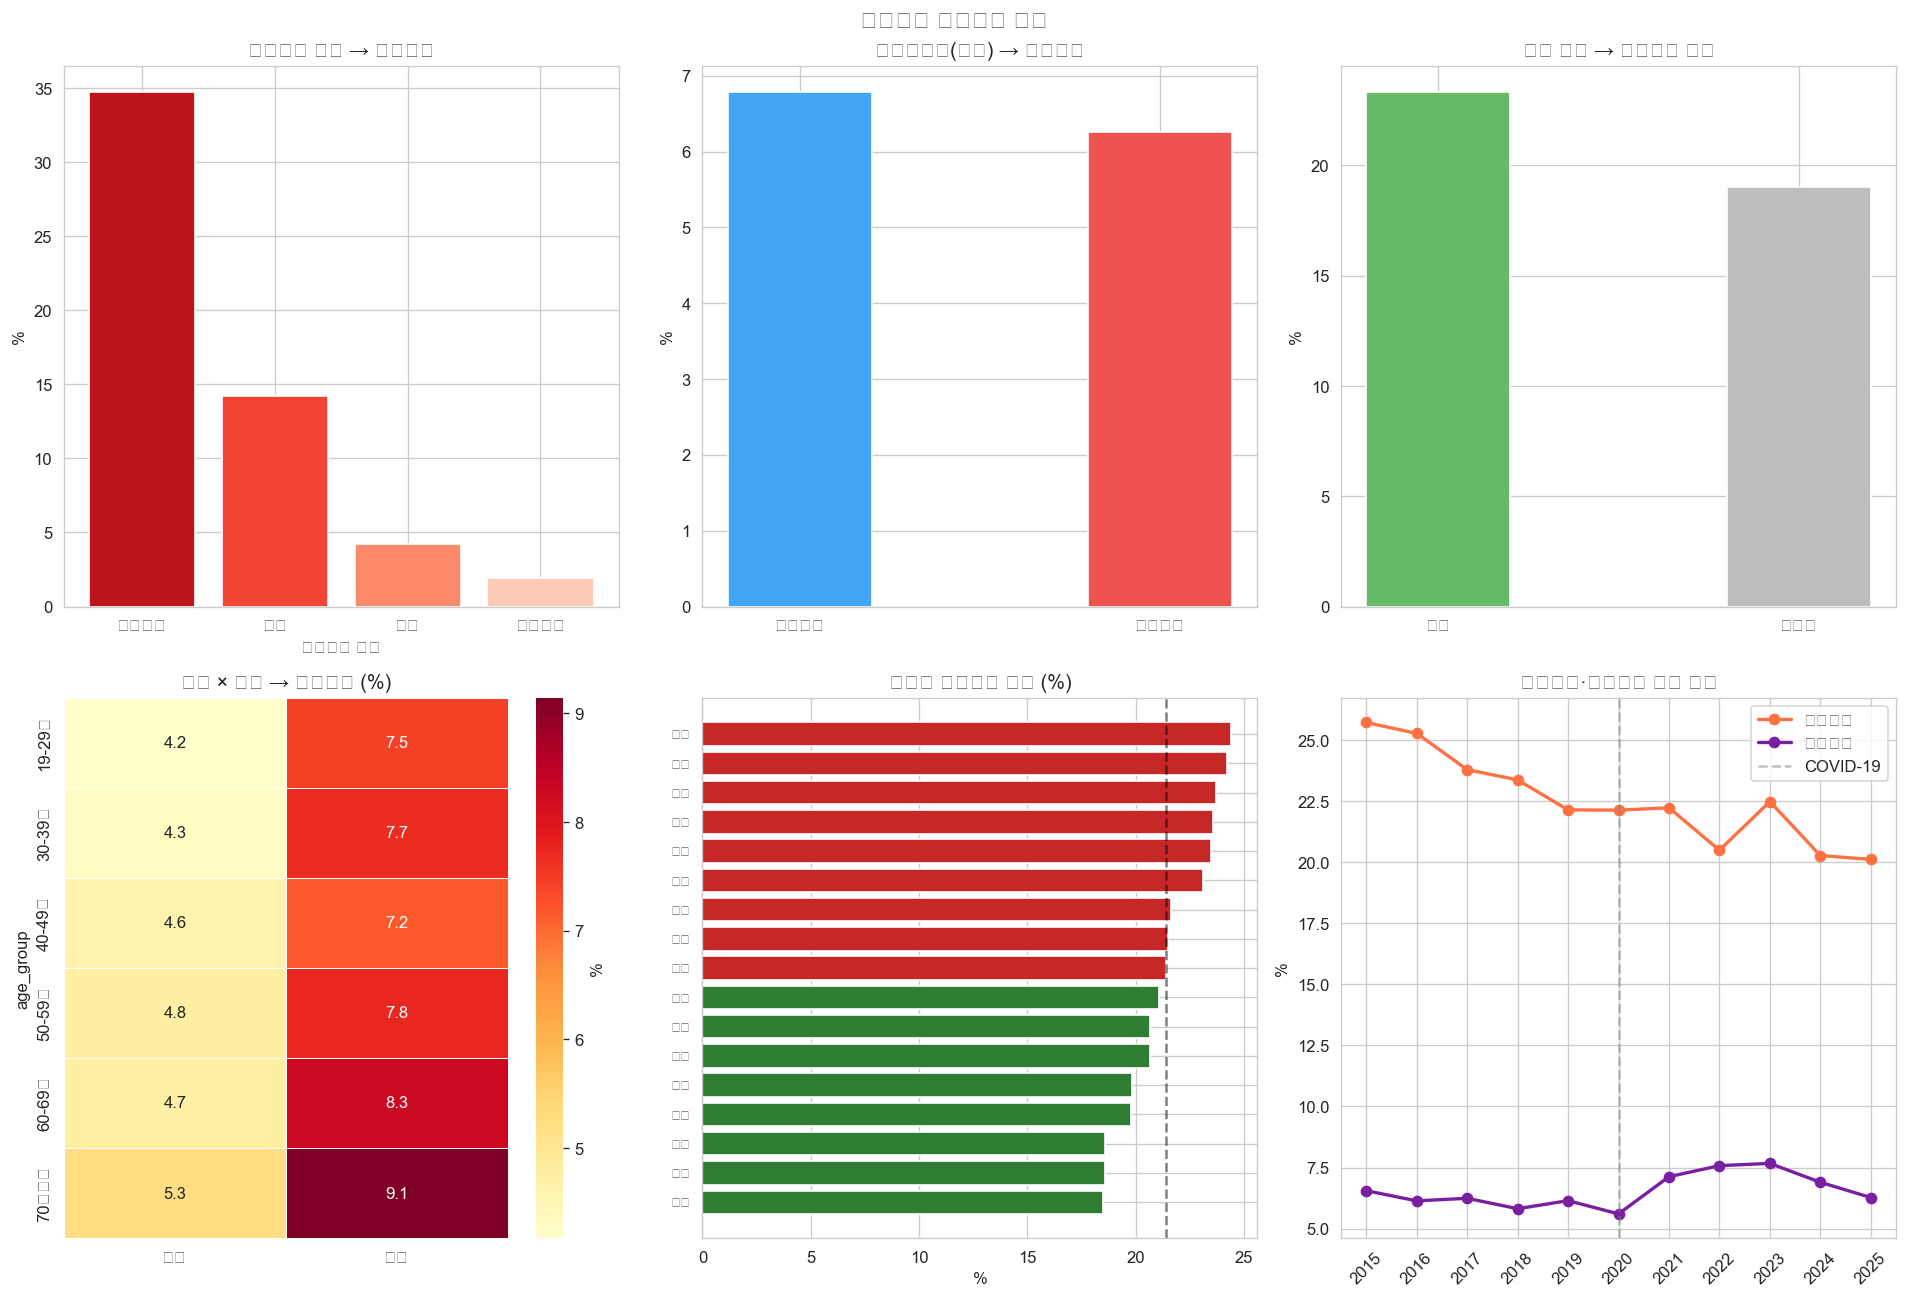

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

# (1) 스트레스 수준별 우울증상
stress_dep = df_all.groupby('mta_01z1')['우울증상'].mean().mul(100).dropna()
stress_lbl = {1:'매우많음', 2:'많음', 3:'조금', 4:'거의없음'}
ax = axes[0][0]
ax.bar([stress_lbl.get(int(k), str(k)) for k in stress_dep.index],
       stress_dep.values, color=sns.color_palette('Reds_r', len(stress_dep)))
ax.set_title('스트레스 수준 → 우울증상')
ax.set_ylabel('%')
ax.set_xlabel('스트레스 수준')

# (2) 사회적자본 × 우울증상
sca_dep = df_all.groupby('sca_01z1')['우울증상'].mean().mul(100).dropna()
sca_lbl = {1:'신뢰높음', 2:'신뢰낮음'}
ax = axes[0][1]
ax.bar([sca_lbl.get(int(k), str(k)) for k in sca_dep.index],
       sca_dep.values, color=['#42A5F5','#EF5350'], width=0.4)
ax.set_title('사회적자본(신뢰) → 우울증상')
ax.set_ylabel('%')

# (3) 음주 × 스트레스
drink_str = df_all.groupby('dra_01z1')['스트레스_많음'].mean().mul(100).dropna()
drink_lbl = {1:'음주', 2:'비음주'}
ax = axes[0][2]
ax.bar([drink_lbl.get(int(k), str(k)) for k in drink_str.index],
       drink_str.values, color=['#66BB6A','#BDBDBD'], width=0.4)
ax.set_title('음주 여부 → 스트레스 많음')
ax.set_ylabel('%')

# (4) 성별 × 나이 × 우울증상 히트맵
pivot_dep = df_all.groupby(['age_group','성별'], observed=True)['우울증상'].mean().unstack().mul(100)
sns.heatmap(pivot_dep, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1][0],
            linewidths=0.5, cbar_kws={'label':'%'})
axes[1][0].set_title('나이 × 성별 → 우울증상 (%)')
axes[1][0].set_xlabel('')

# (5) 지역별 스트레스
if '지역' in df_new.columns:
    r_stress = df_new.groupby('지역')['스트레스_많음'].mean().mul(100).sort_values()
    colors_r = ['#2E7D32' if v < r_stress.median() else '#C62828' for v in r_stress.values]
    axes[1][1].barh(range(len(r_stress)), r_stress.values, color=colors_r)
    axes[1][1].set_yticks(range(len(r_stress)))
    axes[1][1].set_yticklabels(r_stress.index, fontsize=8)
    axes[1][1].axvline(r_stress.median(), color='black', linestyle='--', alpha=0.5)
    axes[1][1].set_title('지역별 스트레스 많음 (%)')
    axes[1][1].set_xlabel('%')

# (6) 스트레스 × 우울 연도 추이
ax = axes[1][2]
for col, color, label in [('스트레스_많음','#FF7043','스트레스'),('우울증상','#7B1FA2','우울증상')]:
    trend = df_all.groupby('year')[col].mean().mul(100)
    ax.plot(trend.index, trend.values, marker='o', color=color, label=label, linewidth=2)
ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5, label='COVID-19')
ax.set_title('스트레스·우울증상 연도 추이')
ax.set_ylabel('%')
ax.set_xticks(sorted(df_all['year'].unique()))
ax.set_xticklabels(sorted(df_all['year'].unique()), rotation=45)
ax.legend()

plt.suptitle('정신건강 위험요인 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. 상관관계 분석

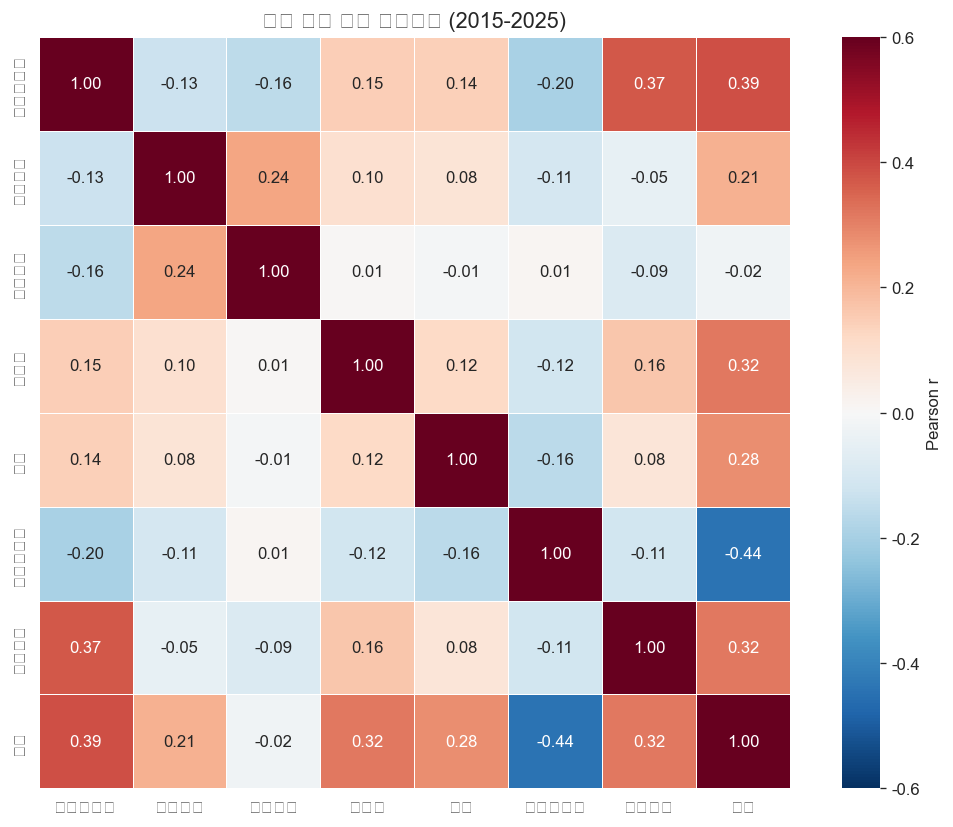

In [22]:
# 전체 연도 핵심 변수 상관관계
corr_raw = ['qoa_01z1','mta_01z1','mtb_01z1','obb_01z1',
             'dra_01z1','sca_01z1','ora_01z1','age']
corr_lbl = ['주관적건강','스트레스','우울증상','비만도',
             '음주','사회적자본','구강건강','나이']

corr_df = df_all[[c for c in corr_raw if c in df_all.columns]].copy()
corr_df.columns = [corr_lbl[corr_raw.index(c)] for c in corr_df.columns]
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, vmin=-0.6, vmax=0.6,
            cbar_kws={'label':'Pearson r'})
ax.set_title('핵심 건강 변수 상관관계 (2015-2025)', fontsize=13)
plt.tight_layout()
plt.show()


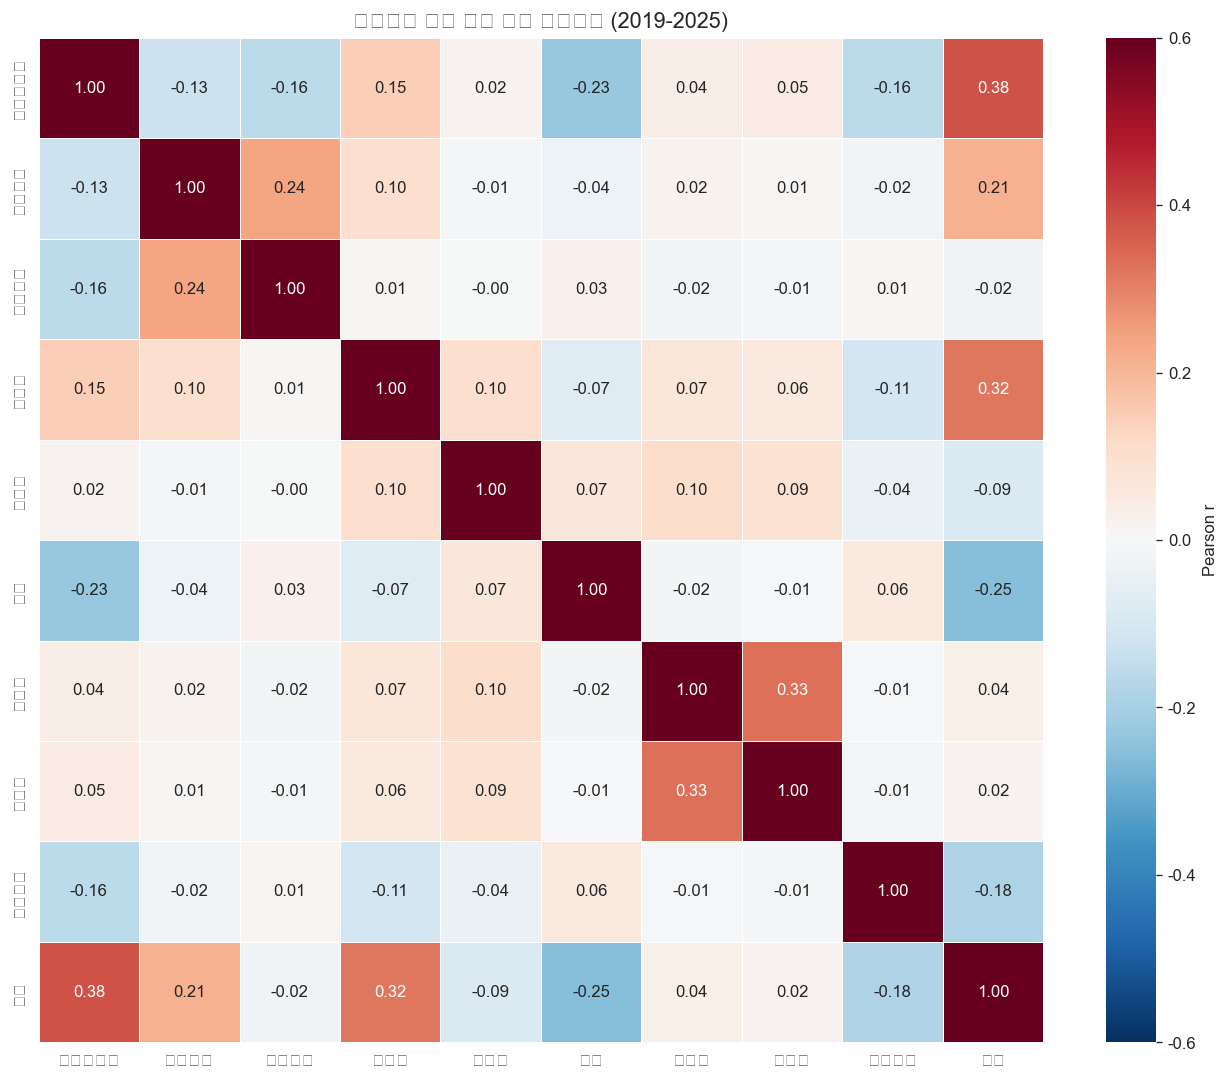

In [23]:
# 2019+ 만성질환 포함 확장 상관관계
ext_raw = ['qoa_01z1','mta_01z1','mtb_01z1','obb_01z1',
            'hya_19z1','dia_04z1','cva_12z1','mya_14z1',
            'pha_04z1','age']
ext_lbl = ['주관적건강','스트레스','우울증상','비만도',
            '고혈압','당뇨','뇌졸중','관절염','걷기일수','나이']

avail_ext = [(r, l) for r, l in zip(ext_raw, ext_lbl) if r in df_new.columns]
ext_df = df_new[[r for r, _ in avail_ext]].copy()
ext_df.columns = [l for _, l in avail_ext]
ext_matrix = ext_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(ext_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, vmin=-0.6, vmax=0.6,
            cbar_kws={'label':'Pearson r'})
ax.set_title('만성질환 포함 건강 변수 상관관계 (2019-2025)', fontsize=13)
plt.tight_layout()
plt.show()


## 12. 다차원 심층 분석

유의미한 상호작용 패턴과 COVID-19 전후 변화를 분석합니다.

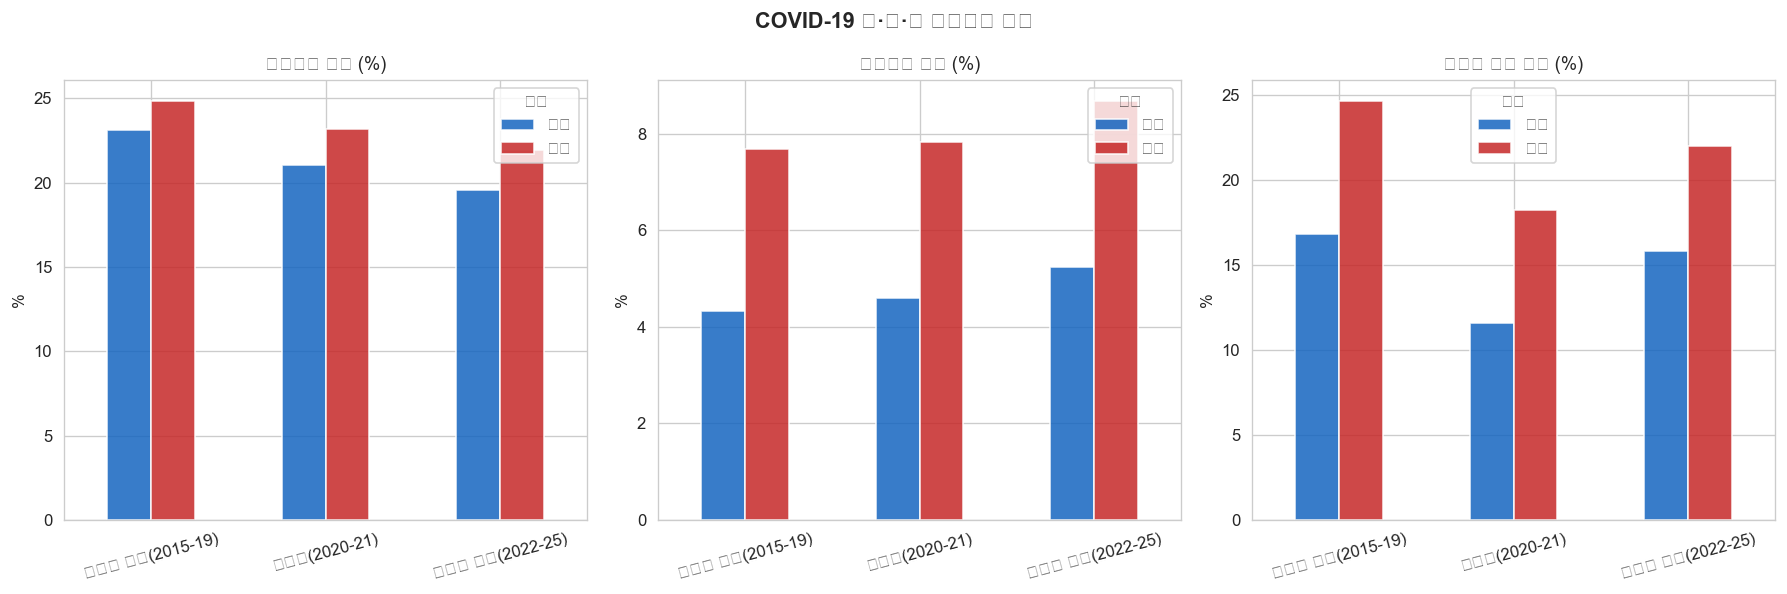

In [24]:
# ── COVID-19 전후 정신건강 변화 ──
df_all['시기'] = df_all['year'].apply(lambda y: '코로나 이전(2015-19)' if y < 2020
                                      else ('코로나(2020-21)' if y <= 2021
                                            else '코로나 이후(2022-25)'))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
covid_cols = ['스트레스_많음', '우울증상', '건강나쁨']
covid_titles = ['스트레스 많음 (%)', '우울증상 경험 (%)', '주관적 건강 나쁨 (%)']

for ax, col, title in zip(axes, covid_cols, covid_titles):
    pivot = df_all.groupby(['시기', '성별'])[col].mean().unstack().mul(100)
    order = ['코로나 이전(2015-19)', '코로나(2020-21)', '코로나 이후(2022-25)']
    pivot = pivot.reindex([o for o in order if o in pivot.index])
    pivot.plot(kind='bar', ax=ax, color=colors_gd, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('%')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='성별')

plt.suptitle('COVID-19 전·중·후 정신건강 변화', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


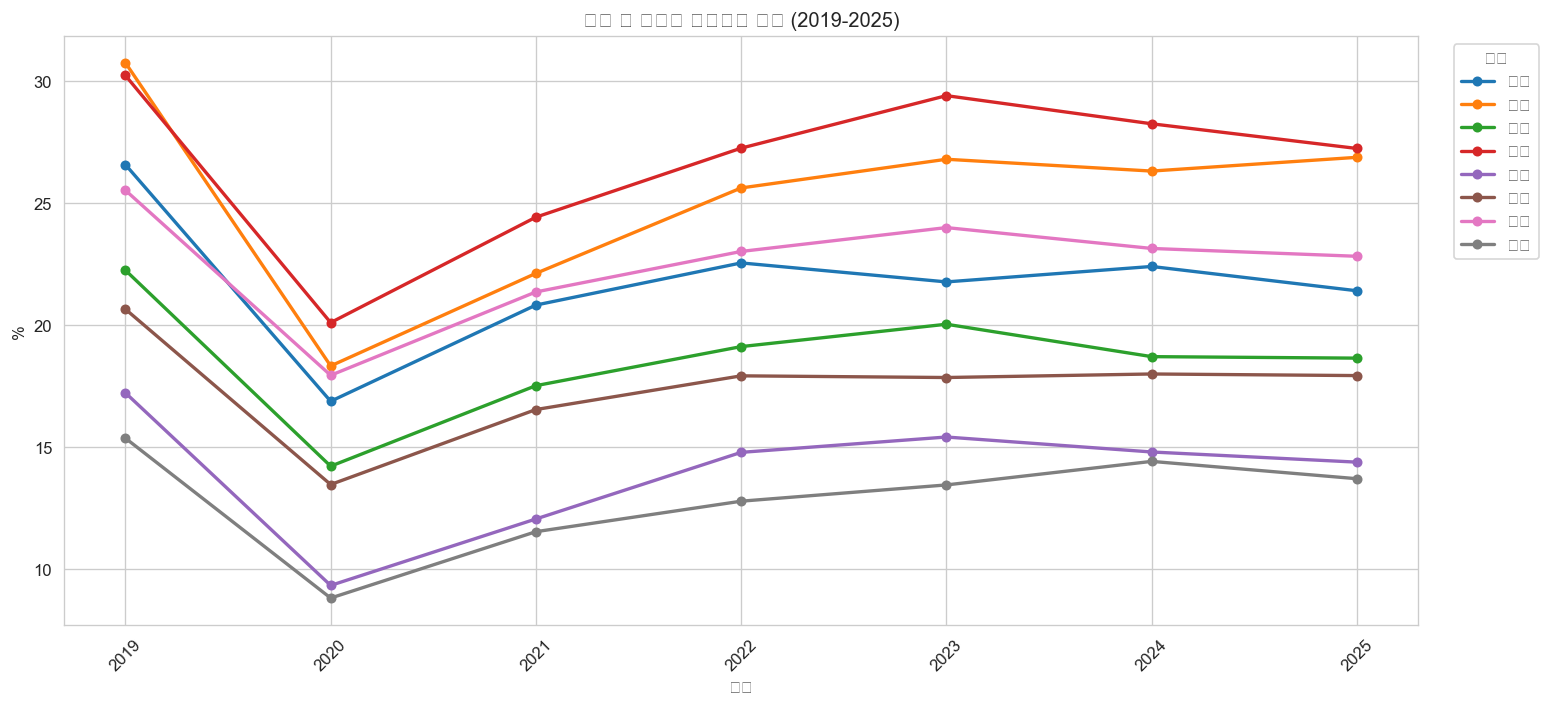

In [25]:
# ── 지역 × 연도 트렌드 (건강나쁨) ──
if '지역' in df_new.columns:
    region_trend = df_new.groupby(['year','지역'])['건강나쁨'].mean().unstack().mul(100)
    # 가장 변화가 큰 지역 상위 5개 추출
    change = region_trend.iloc[-1] - region_trend.iloc[0]
    top_regions = change.abs().nlargest(8).index.tolist()

    fig, ax = plt.subplots(figsize=(13, 6))
    for region in top_regions:
        if region in region_trend.columns:
            ax.plot(region_trend.index, region_trend[region],
                    marker='o', label=region, linewidth=2, markersize=5)
    ax.set_title('변화 큰 지역별 건강나쁨 추이 (2019-2025)', fontsize=12)
    ax.set_xlabel('연도')
    ax.set_ylabel('%')
    ax.set_xticks(region_trend.index)
    ax.set_xticklabels(region_trend.index, rotation=45)
    ax.legend(title='지역', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


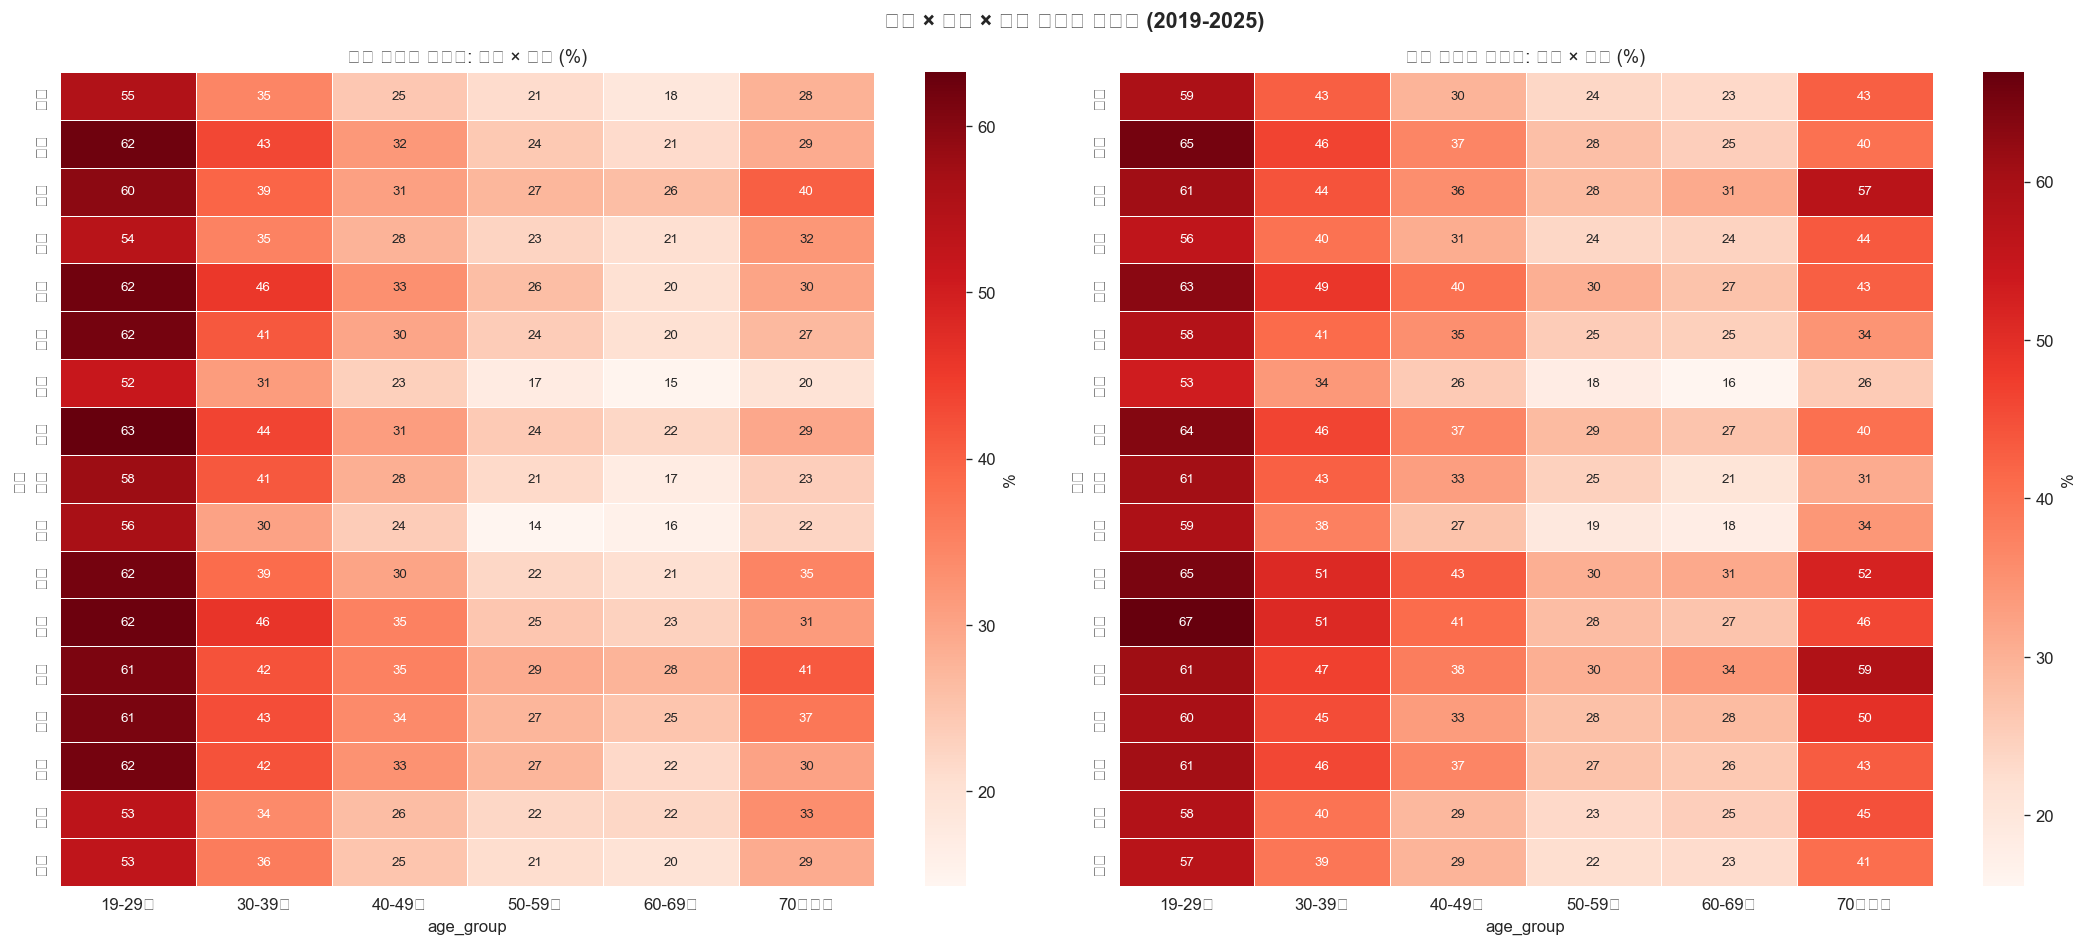

In [26]:
# ── 성별 × 나이 × 지역 - 고혈압 유병률 히트맵 (2019+) ──
if '고혈압' in df_new.columns and '지역' in df_new.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    for ax, gender in zip(axes, ['남성', '여성']):
        sub = df_new[df_new['성별'] == gender]
        pivot = sub.groupby(['지역','age_group'], observed=True)['고혈압'].mean().unstack().mul(100)
        pivot = pivot.reindex(sorted(pivot.index))
        sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds',
                    ax=ax, linewidths=0.3, cbar_kws={'label':'%'}, annot_kws={'size':8})
        ax.set_title(f'{gender} 고혈압 유병률: 지역 × 나이 (%)', fontsize=11)
    plt.suptitle('성별 × 지역 × 나이 고혈압 유병률 (2019-2025)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


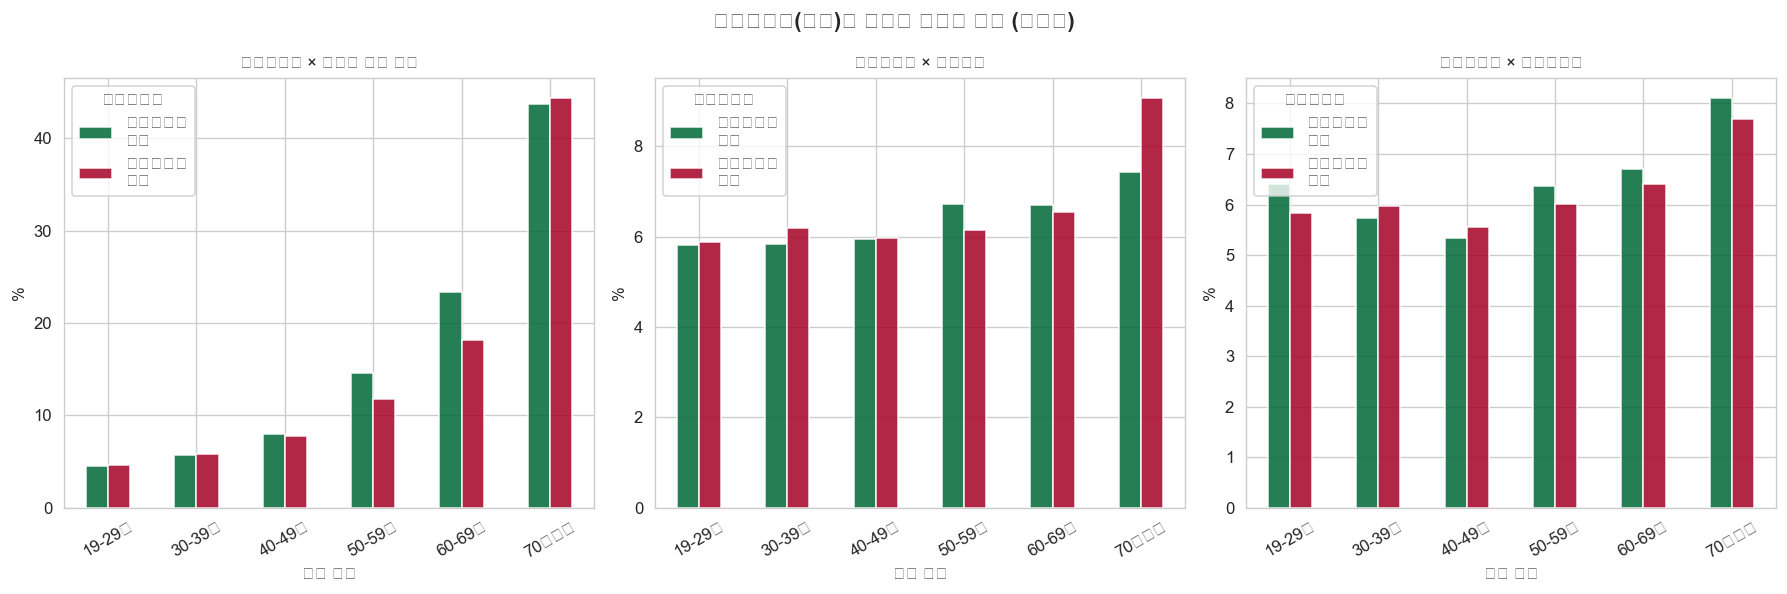

In [27]:
# ── 사회적자본 × 건강 격차 ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sca_outcomes = ['건강나쁨', '우울증상', '미충족의료']
sca_titles   = ['주관적 건강 나쁨', '우울증상', '미충족의료']
sca_lbl_map  = {1:'사회적신뢰\n높음', 2:'사회적신뢰\n낮음'}

for ax, col, title in zip(axes, sca_outcomes, sca_titles):
    # 나이그룹별 사회적자본 효과
    pivot = df_all.groupby(['sca_01z1','age_group'], observed=True)[col].mean().unstack().mul(100)
    pivot.index = [sca_lbl_map.get(int(k), str(k)) for k in pivot.index]
    pivot.T.plot(kind='bar', ax=ax, colormap='RdYlGn_r', alpha=0.85)
    ax.set_title(f'사회적자본 × {title}', fontsize=10)
    ax.set_ylabel('%')
    ax.set_xlabel('나이 그룹')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='사회적자본')

plt.suptitle('사회적자본(신뢰)이 건강에 미치는 영향 (나이별)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [28]:
# ── 건강불평등 요약: 지역 × 성별 × 나이 ──
print("=" * 55)
print("  유의미한 건강 관계 요약 (2015-2025)")
print("=" * 55)

summary = {}

# 연도 트렌드 변화량
for col, label in [('건강나쁨','건강나쁨'), ('우울증상','우울증상'), ('스트레스_많음','스트레스')]:
    trend = df_all.groupby('year')[col].mean().mul(100)
    chg = trend.iloc[-1] - trend.iloc[0]
    summary[label+'_변화'] = chg

# 성별 격차
for col, label in [('우울증상','우울증상'), ('스트레스_많음','스트레스')]:
    g = df_all.groupby('성별')[col].mean().mul(100)
    if '남성' in g.index and '여성' in g.index:
        summary[label+'_성별격차'] = g['여성'] - g['남성']

# 나이 극단 격차 (70세이상 vs 19-29세)
for col, label in [('건강나쁨','건강나쁨'), ('고혈압','고혈압'), ('당뇨','당뇨')]:
    src = df_new if col in df_new.columns else df_all
    ag = src.groupby('age_group', observed=True)[col].mean().mul(100)
    if '19-29세' in ag.index and '70세이상' in ag.index:
        summary[label+'_나이격차(70-29)'] = ag['70세이상'] - ag['19-29세']

for k, v in summary.items():
    direction = '↑' if v > 0 else '↓'
    print(f"  {k:<28}: {v:+.1f}%p {direction}")


  유의미한 건강 관계 요약 (2015-2025)
  건강나쁨_변화                     : -2.1%p ↓
  우울증상_변화                     : -0.3%p ↓
  스트레스_변화                     : -5.6%p ↓
  우울증상_성별격차                   : +3.4%p ↑
  스트레스_성별격차                   : +2.0%p ↑
  건강나쁨_나이격차(70-29)            : +36.6%p ↑
  고혈압_나이격차(70-29)             : -20.6%p ↓
  당뇨_나이격차(70-29)              : +23.9%p ↑


## 13. 지역별 삶의 질 격차 — 건강 심층 EDA

> **대주제**: 지역별 삶의 질 격차 분석  
> **담당 파트**: 건강 × 지역 관계

### 분석 구조 (스토리라인)
```
① 도시-농촌 기본 격차     → 광역시 vs 도·군, 어디가 더 건강한가?
② 의료 접근성 격차        → 미충족의료율이 높은 지역에서 건강결과도 나쁜가?
③ 건강취약 종합지수       → 어느 지역이 다차원적으로 가장 취약한가?
④ 사회적자본 완충 효과    → 사회적 신뢰가 높은 지역은 건강격차가 작은가?
⑤ 만성질환 복합 부담      → 고혈압·당뇨가 겹치는 지역은 어디인가?
⑥ COVID-19 전후 변화      → 코로나 이후 지역별 건강격차가 심화됐는가?
```

**사용 데이터**: df_all (2015-2025 전체) + df_new (2019-2025 풍부한 변수)

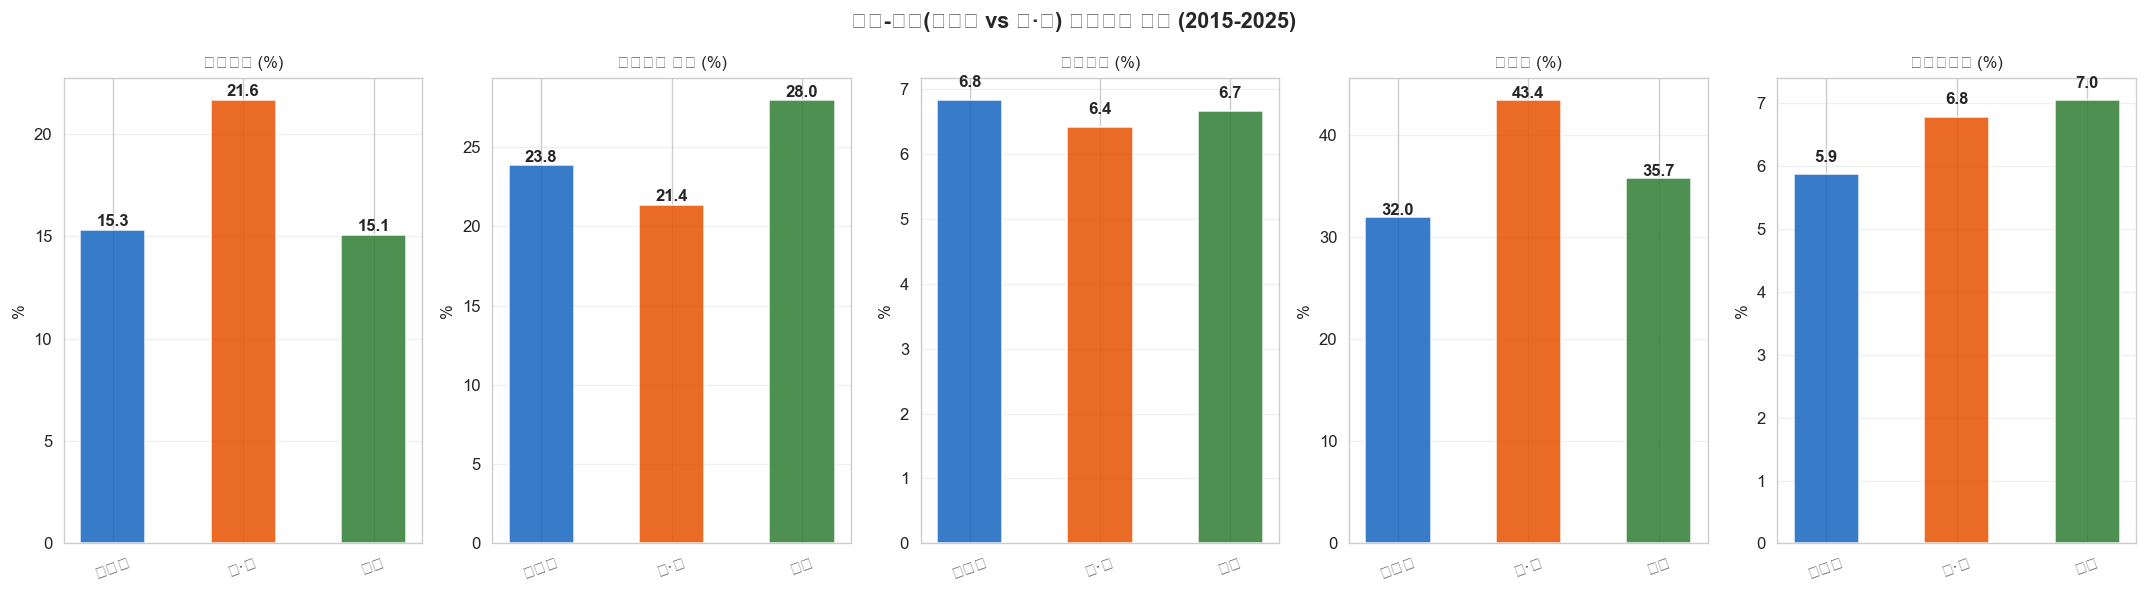

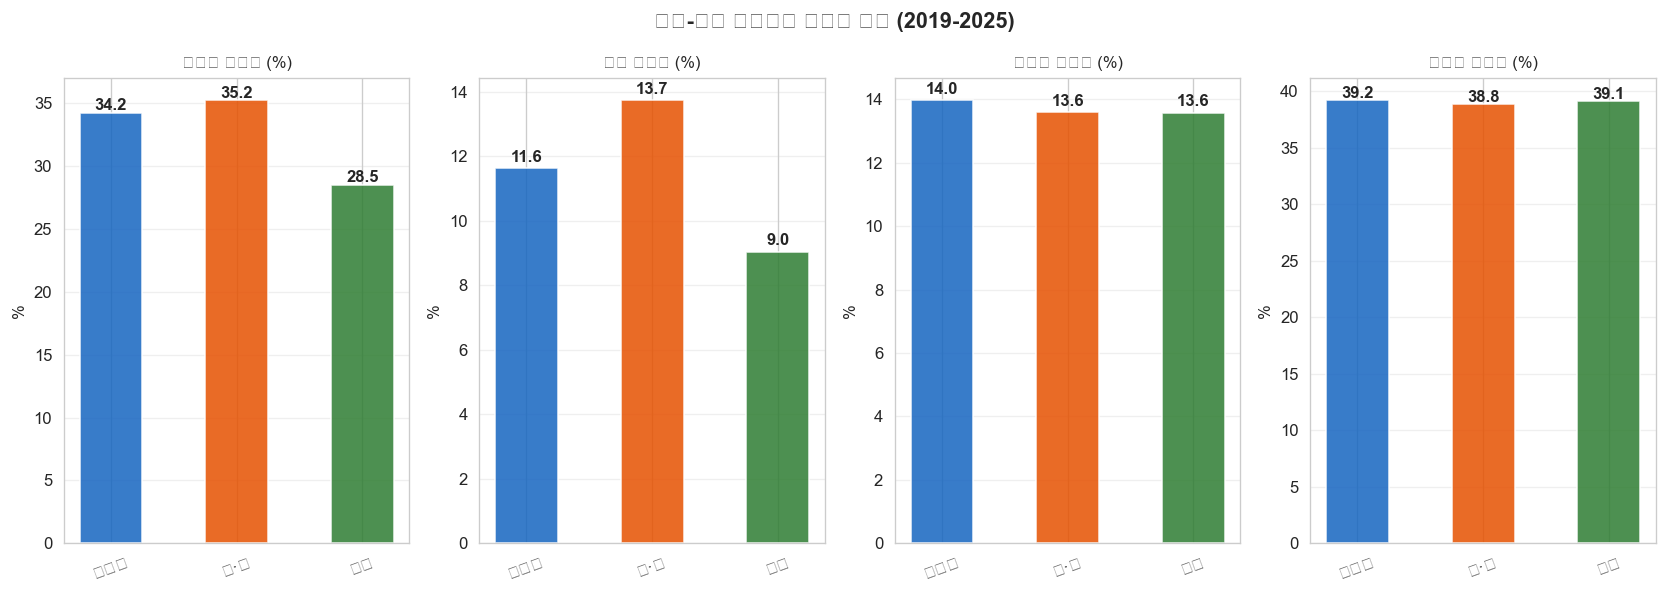


[도시-농촌 건강격차 요약 (광역시 대비 도·군)]
  건강나쁨           : +6.3%p  (도·군이 더 나쁨 ↑)
  스트레스_많음        : -2.5%p  (광역시가 더 나쁨 ↑)
  우울증상           : -0.4%p  (광역시가 더 나쁨 ↑)
  비만             : +11.4%p  (도·군이 더 나쁨 ↑)
  미충족의료          : +0.9%p  (도·군이 더 나쁨 ↑)


In [29]:
# ① 도시-농촌 지역유형 분류 & 건강지표 비교
urban_codes = {11, 26, 27, 28, 29, 30, 31}  # 7개 광역시

def classify_region(code):
    if code in urban_codes:
        return '광역시'
    elif code == 36:
        return '세종'
    else:
        return '도·군'

df_all['지역유형'] = df_all['region'].apply(classify_region)
df_new['지역유형'] = df_new['region'].apply(classify_region)

type_order  = ['광역시', '도·군', '세종']
type_cols   = ['건강나쁨', '스트레스_많음', '우울증상', '비만', '미충족의료']
type_titles = ['건강나쁨 (%)', '스트레스 많음 (%)', '우울증상 (%)', '비만율 (%)', '미충족의료 (%)']
colors_type = ['#1565C0', '#E65100', '#2E7D32']

type_stats = (df_all.groupby('지역유형')[type_cols].mean().mul(100)
              .reindex([t for t in type_order if t in df_all['지역유형'].unique()]))

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col, title in zip(axes, type_cols, type_titles):
    vals = type_stats[col]
    bars = ax.bar(vals.index, vals.values,
                  color=colors_type[:len(vals)], width=0.5, alpha=0.85)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('도시-농촌(광역시 vs 도·군) 건강지표 비교 (2015-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2019+ 만성질환 도시-농촌 비교
chronic_type = [c for c in ['고혈압', '당뇨', '뇌졸중', '관절염'] if c in df_new.columns]
if chronic_type:
    type_chronic = (df_new.groupby('지역유형')[chronic_type].mean().mul(100)
                    .reindex([t for t in type_order if t in df_new['지역유형'].unique()]))
    fig, axes = plt.subplots(1, len(chronic_type), figsize=(14, 5))
    for ax, col in zip(axes, chronic_type):
        vals = type_chronic[col]
        bars = ax.bar(vals.index, vals.values,
                      color=colors_type[:len(vals)], width=0.5, alpha=0.85)
        for bar, val in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
        ax.set_title(f'{col} 유병률 (%)', fontsize=10)
        ax.set_ylabel('%')
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle('도시-농촌 만성질환 유병률 비교 (2019-2025)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n[도시-농촌 건강격차 요약 (광역시 대비 도·군)]")
if '광역시' in type_stats.index and '도·군' in type_stats.index:
    gap = type_stats.loc['도·군'] - type_stats.loc['광역시']
    for col, g in gap.items():
        direction = '도·군이 더 나쁨 ↑' if g > 0 else '광역시가 더 나쁨 ↑'
        print(f"  {col:15s}: {g:+.1f}%p  ({direction})")

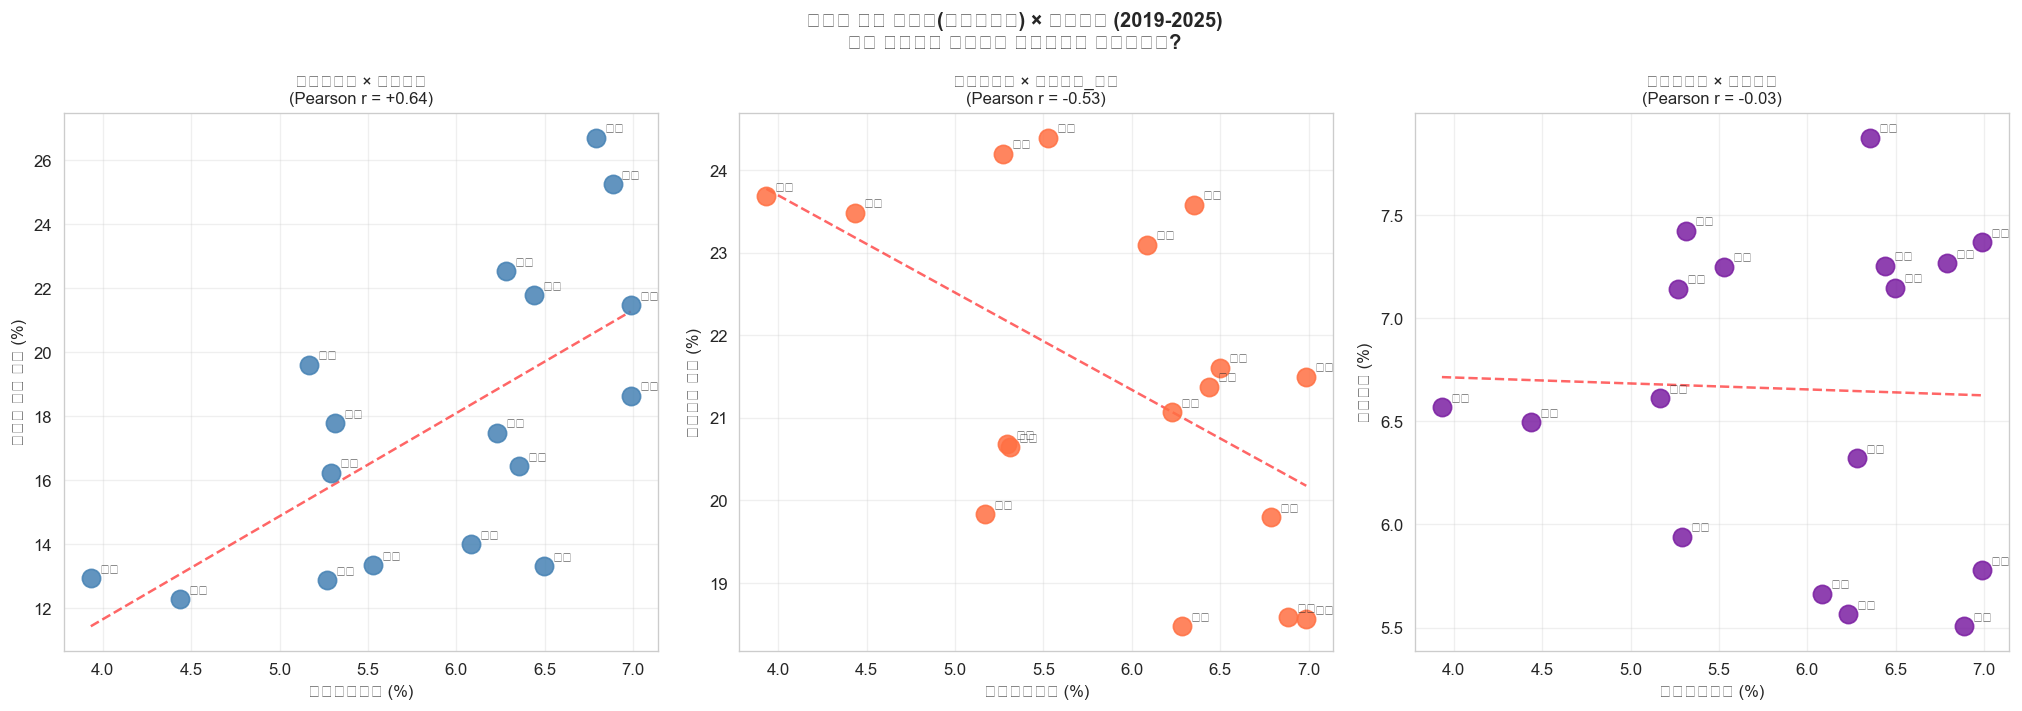

In [30]:
# ② 지역별 의료 접근성 × 건강결과 산점도
r_scatter = (df_new.groupby('지역')[['미충족의료', '건강나쁨', '스트레스_많음', '우울증상']]
             .mean().mul(100).dropna())

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
scatter_pairs = [
    ('건강나쁨',     'steelblue', '주관적 건강 나쁨 (%)'),
    ('스트레스_많음', '#FF7043',  '스트레스 많음 (%)'),
    ('우울증상',     '#7B1FA2',   '우울증상 (%)'),
]

for ax, (ycol, color, ylabel) in zip(axes, scatter_pairs):
    x = r_scatter['미충족의료'].values
    y = r_scatter[ycol].values
    ax.scatter(x, y, s=120, color=color, zorder=3, alpha=0.85)
    for region, row in r_scatter.iterrows():
        ax.annotate(region, (row['미충족의료'], row[ycol]),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    z = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), 'r--', alpha=0.6, linewidth=1.5)
    r_val = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel('미충족의료율 (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'미충족의료 × {ycol}\n(Pearson r = {r_val:+.2f})', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('지역별 의료 접근성(미충족의료) × 건강결과 (2019-2025)\n의료 접근성이 낮을수록 건강결과도 나빠지는가?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

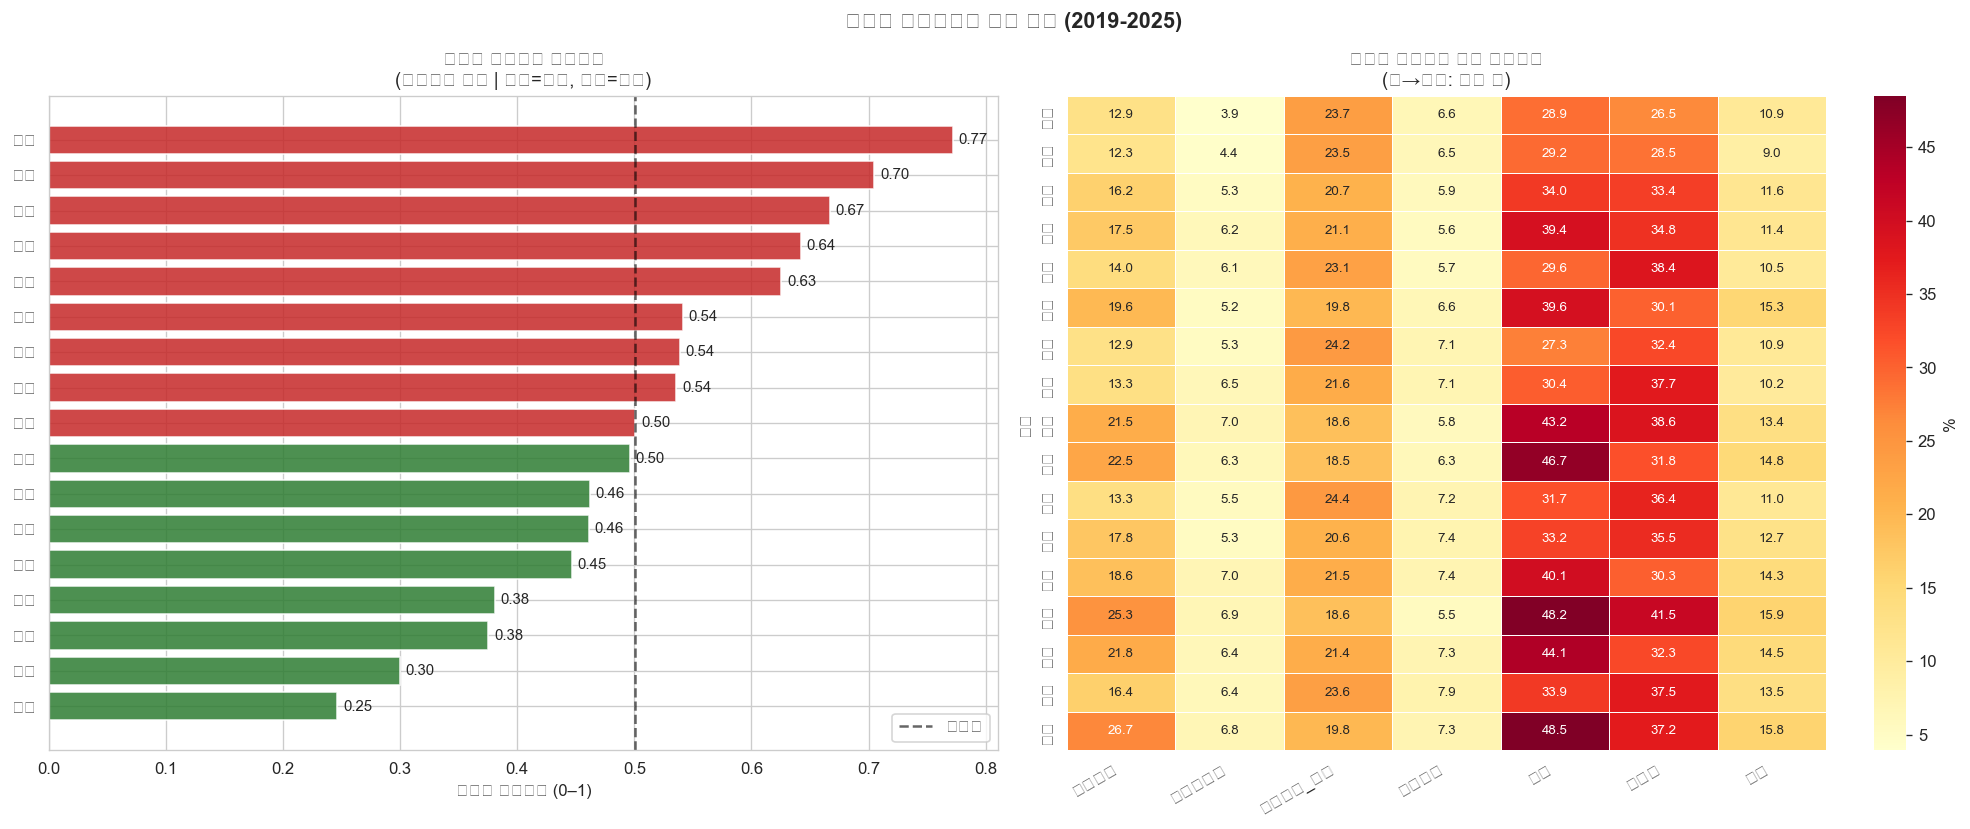

In [31]:
# ③ 지역별 건강취약 종합지수 심화 (미충족의료 + PHQ-9 포함)
ext_score_cols = [c for c in ['건강나쁨', '미충족의료', '스트레스_많음', '우울증상',
                               '비만', '고혈압', '당뇨'] if c in df_new.columns]
r_ext = df_new.groupby('지역')[ext_score_cols].mean().mul(100).dropna(how='all')

r_norm = (r_ext - r_ext.min()) / (r_ext.max() - r_ext.min())

if 'PHQ9_총점' in df_new.columns:
    phq_r = df_new.groupby('지역')['PHQ9_총점'].mean().dropna()
    phq_n = (phq_r - phq_r.min()) / (phq_r.max() - phq_r.min())
    r_norm['PHQ9'] = phq_n

r_norm['건강취약종합지수'] = r_norm[[c for c in r_norm.columns if c != '건강취약종합지수']].mean(axis=1)
r_idx_sorted = r_norm['건강취약종합지수'].sort_values()

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

colors_idx = ['#2E7D32' if v < r_idx_sorted.median() else '#C62828' for v in r_idx_sorted.values]
bars = axes[0].barh(range(len(r_idx_sorted)), r_idx_sorted.values, color=colors_idx, alpha=0.85)
axes[0].set_yticks(range(len(r_idx_sorted)))
axes[0].set_yticklabels(r_idx_sorted.index)
axes[0].axvline(r_idx_sorted.median(), color='black', linestyle='--', alpha=0.6, label='중앙값')
for bar, val in zip(bars, r_idx_sorted.values):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[0].set_title('지역별 건강취약 종합지수\n(높을수록 취약 | 초록=양호, 빨강=취약)', fontsize=11)
axes[0].set_xlabel('정규화 종합지수 (0–1)')
axes[0].legend()

hm_cols = [c for c in ['건강나쁨', '미충족의료', '스트레스_많음', '우울증상', '비만', '고혈압', '당뇨']
           if c in r_ext.columns]
r_hm = r_ext[hm_cols].reindex(r_idx_sorted.index)
sns.heatmap(r_hm, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.4, cbar_kws={'label': '%'}, annot_kws={'size': 8})
axes[1].set_title('지역별 건강지표 상세 프로파일\n(위→아래: 취약 순)', fontsize=11)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle('지역별 건강취약성 종합 분석 (2019-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

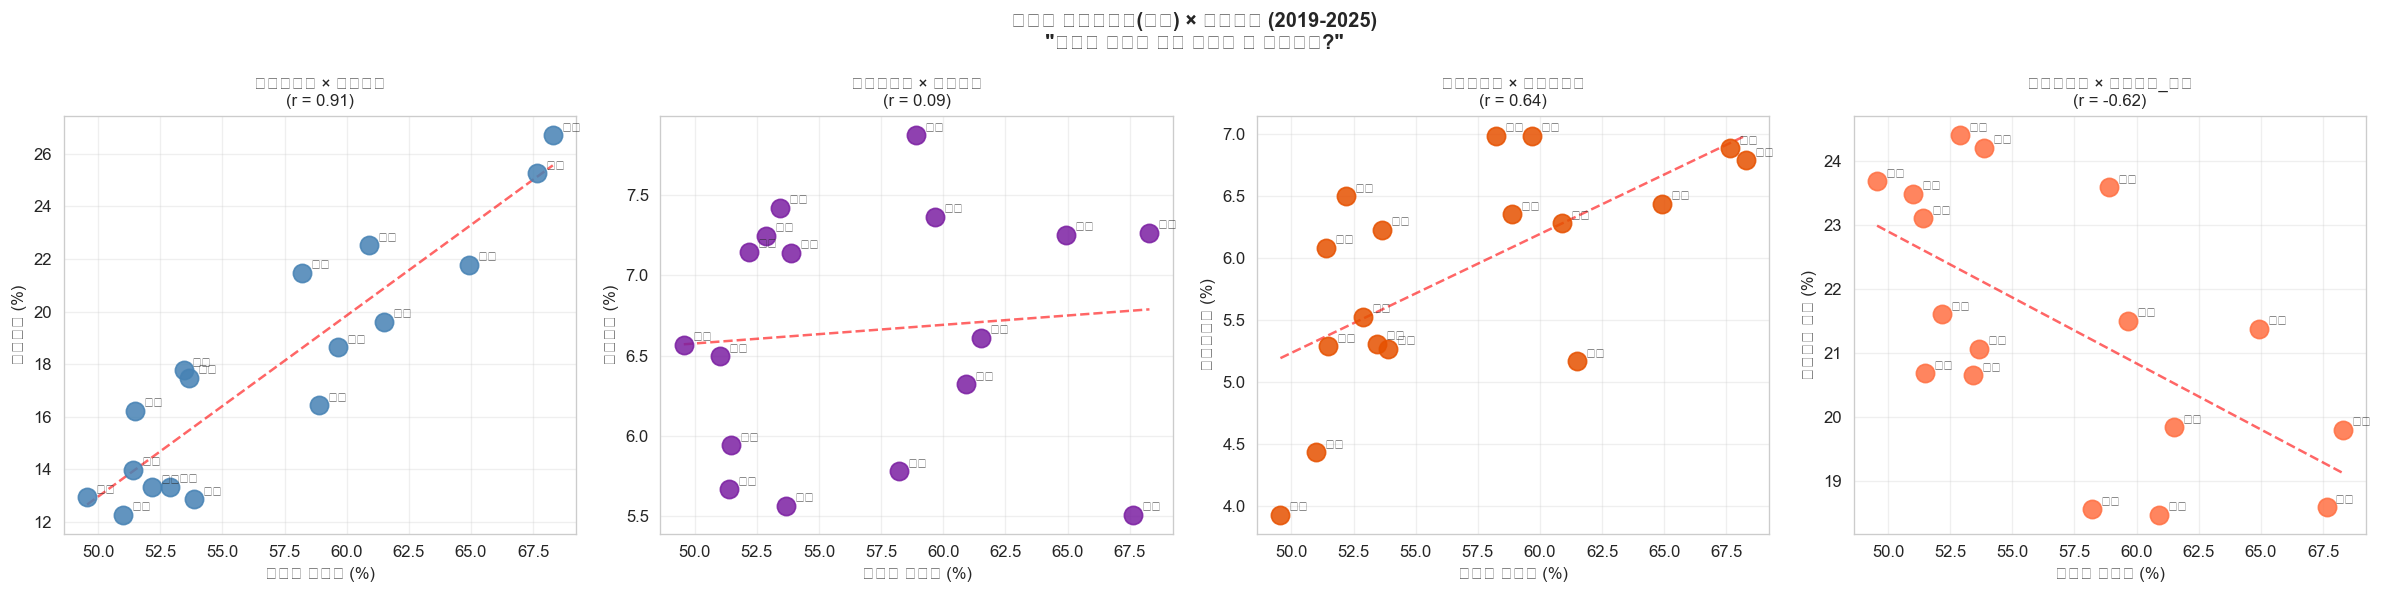


[사회적자본 × 건강 지역 상관계수]
  사회적신뢰 × 건강나쁨      : r = +0.914  신뢰↑→건강악화↑ (역설적)
  사회적신뢰 × 우울증상      : r = +0.093  신뢰↑→건강악화↑ (역설적)
  사회적신뢰 × 미충족의료     : r = +0.637  신뢰↑→건강악화↑ (역설적)
  사회적신뢰 × 스트레스_많음   : r = -0.615  신뢰↑→건강악화↓ (긍정적)


In [32]:
# ④ 사회적자본(신뢰) × 건강결과 지역 산점도
sca_region = (df_new.groupby('지역')['sca_01z1']
              .apply(lambda x: (x == 1).mean() * 100)
              .rename('사회적신뢰율'))
r_health_sca = df_new.groupby('지역')[['건강나쁨', '우울증상', '미충족의료', '스트레스_많음']].mean().mul(100)
r_sca = pd.concat([sca_region, r_health_sca], axis=1).dropna()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sca_pairs = [
    ('건강나쁨',     'steelblue', '건강나쁨 (%)'),
    ('우울증상',     '#7B1FA2',   '우울증상 (%)'),
    ('미충족의료',   '#E65100',   '미충족의료 (%)'),
    ('스트레스_많음', '#FF7043',  '스트레스 많음 (%)'),
]

for ax, (ycol, color, ylabel) in zip(axes, sca_pairs):
    x = r_sca['사회적신뢰율'].values
    y = r_sca[ycol].values
    ax.scatter(x, y, s=120, color=color, zorder=3, alpha=0.85)
    for region, row in r_sca.iterrows():
        ax.annotate(region, (row['사회적신뢰율'], row[ycol]),
                    textcoords='offset points', xytext=(5, 2), fontsize=8)
    z = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, np.poly1d(z)(xline), 'r--', alpha=0.6, linewidth=1.5)
    r_val = np.corrcoef(x, y)[0, 1]
    ax.set_xlabel('사회적 신뢰율 (%)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'사회적신뢰 × {ycol}\n(r = {r_val:.2f})', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('지역별 사회적자본(신뢰) × 건강결과 (2019-2025)\n"사회적 연대가 강한 지역이 더 건강한가?"',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[사회적자본 × 건강 지역 상관계수]")
for ycol, _, _ in sca_pairs:
    r_val = np.corrcoef(r_sca['사회적신뢰율'], r_sca[ycol])[0, 1]
    direction = '신뢰↑→건강악화↓ (긍정적)' if r_val < 0 else '신뢰↑→건강악화↑ (역설적)'
    print(f"  사회적신뢰 × {ycol:10s}: r = {r_val:+.3f}  {direction}")

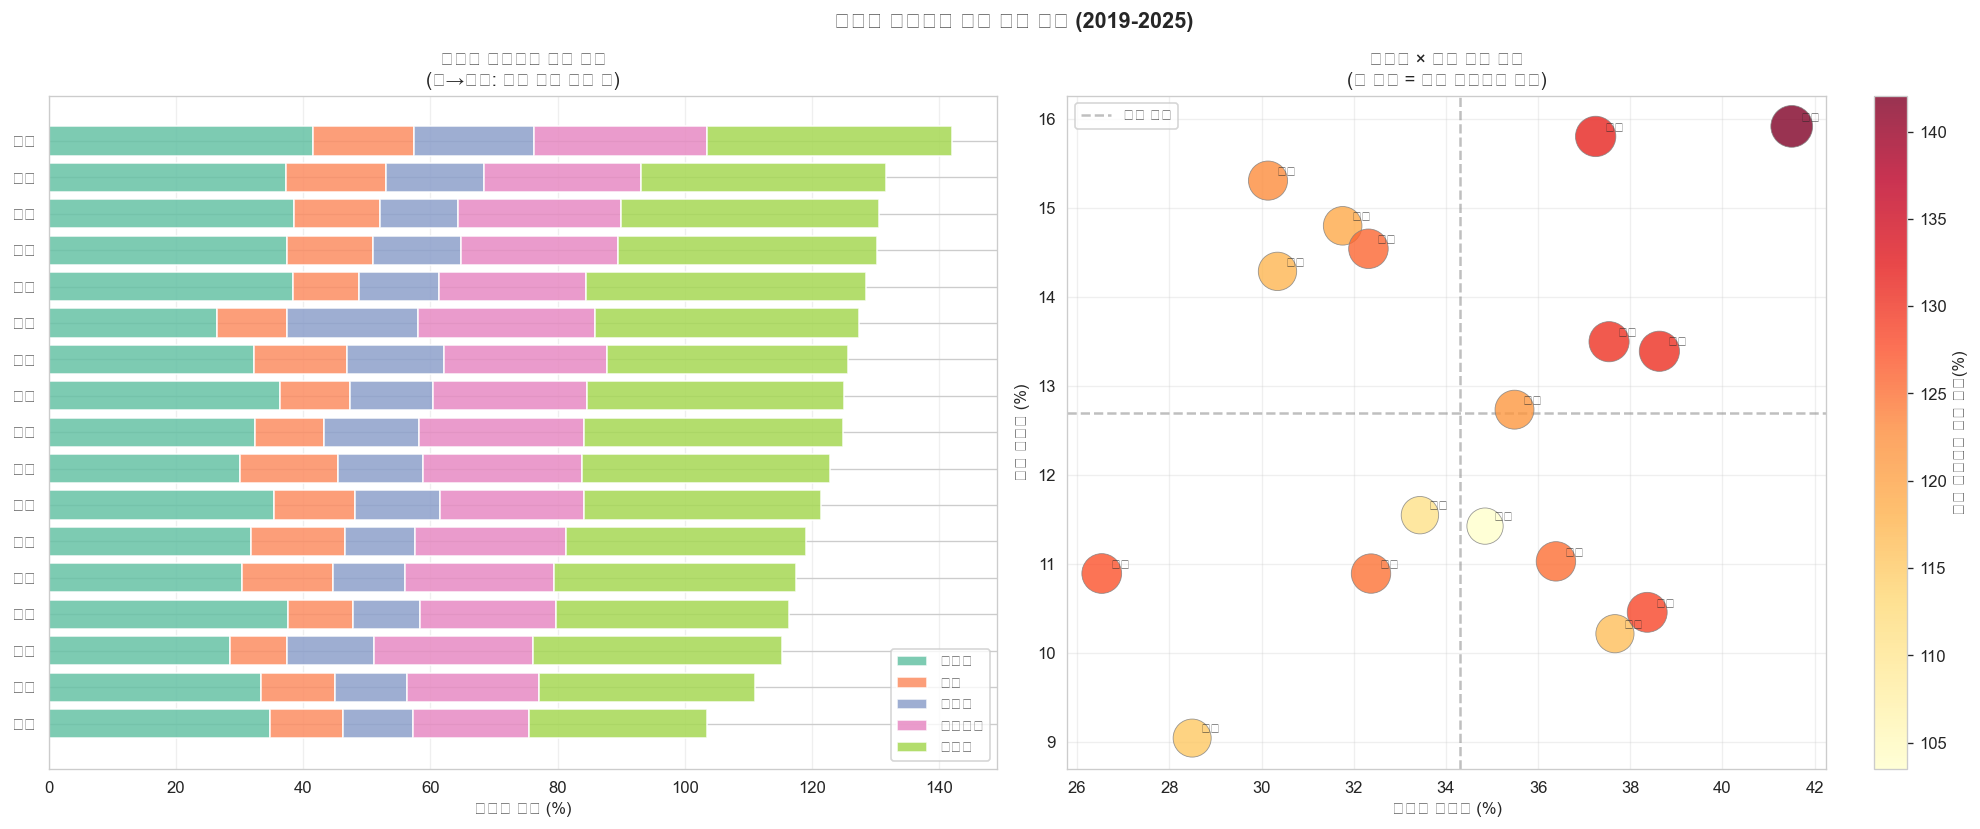

In [33]:
# ⑤ 만성질환 복합 부담 지역 프로파일
chronic_avail = [c for c in ['고혈압', '당뇨', '뇌졸중', '심근경색', '관절염']
                 if c in df_new.columns]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

chronic_r = df_new.groupby('지역')[chronic_avail].mean().mul(100).dropna(how='all')
chronic_r_sorted = chronic_r.sum(axis=1).sort_values(ascending=True)
chronic_r = chronic_r.reindex(chronic_r_sorted.index)

bottom = np.zeros(len(chronic_r))
colors_chronic = sns.color_palette('Set2', len(chronic_avail))
for col, color in zip(chronic_avail, colors_chronic):
    axes[0].barh(range(len(chronic_r)), chronic_r[col].values,
                  left=bottom, color=color, label=col, alpha=0.85)
    bottom += chronic_r[col].fillna(0).values

axes[0].set_yticks(range(len(chronic_r)))
axes[0].set_yticklabels(chronic_r.index)
axes[0].set_xlabel('유병률 합산 (%)')
axes[0].set_title('지역별 만성질환 부담 누적\n(위→아래: 부담 작은 지역 순)', fontsize=11)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

if '고혈압' in chronic_r.columns and '당뇨' in chronic_r.columns:
    x    = chronic_r['고혈압'].values
    y    = chronic_r['당뇨'].values
    size = chronic_r.sum(axis=1).values
    sc   = axes[1].scatter(x, y, s=size * 4 + 60, c=size, cmap='YlOrRd',
                            alpha=0.8, zorder=3, edgecolors='gray', linewidths=0.5)
    for region, row in chronic_r.iterrows():
        axes[1].annotate(region, (row['고혈압'], row['당뇨']),
                          textcoords='offset points', xytext=(5, 3), fontsize=8)
    axes[1].axvline(chronic_r['고혈압'].mean(), color='gray', linestyle='--', alpha=0.5, label='전국 평균')
    axes[1].axhline(chronic_r['당뇨'].mean(),   color='gray', linestyle='--', alpha=0.5)
    plt.colorbar(sc, ax=axes[1], label='전체 만성질환 부담 합산(%)')
    axes[1].set_xlabel('고혈압 유병률 (%)')
    axes[1].set_ylabel('당뇨 유병률 (%)')
    axes[1].set_title('고혈압 × 당뇨 지역 분포\n(원 크기 = 전체 만성질환 부담)', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

plt.suptitle('지역별 만성질환 복합 부담 분석 (2019-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

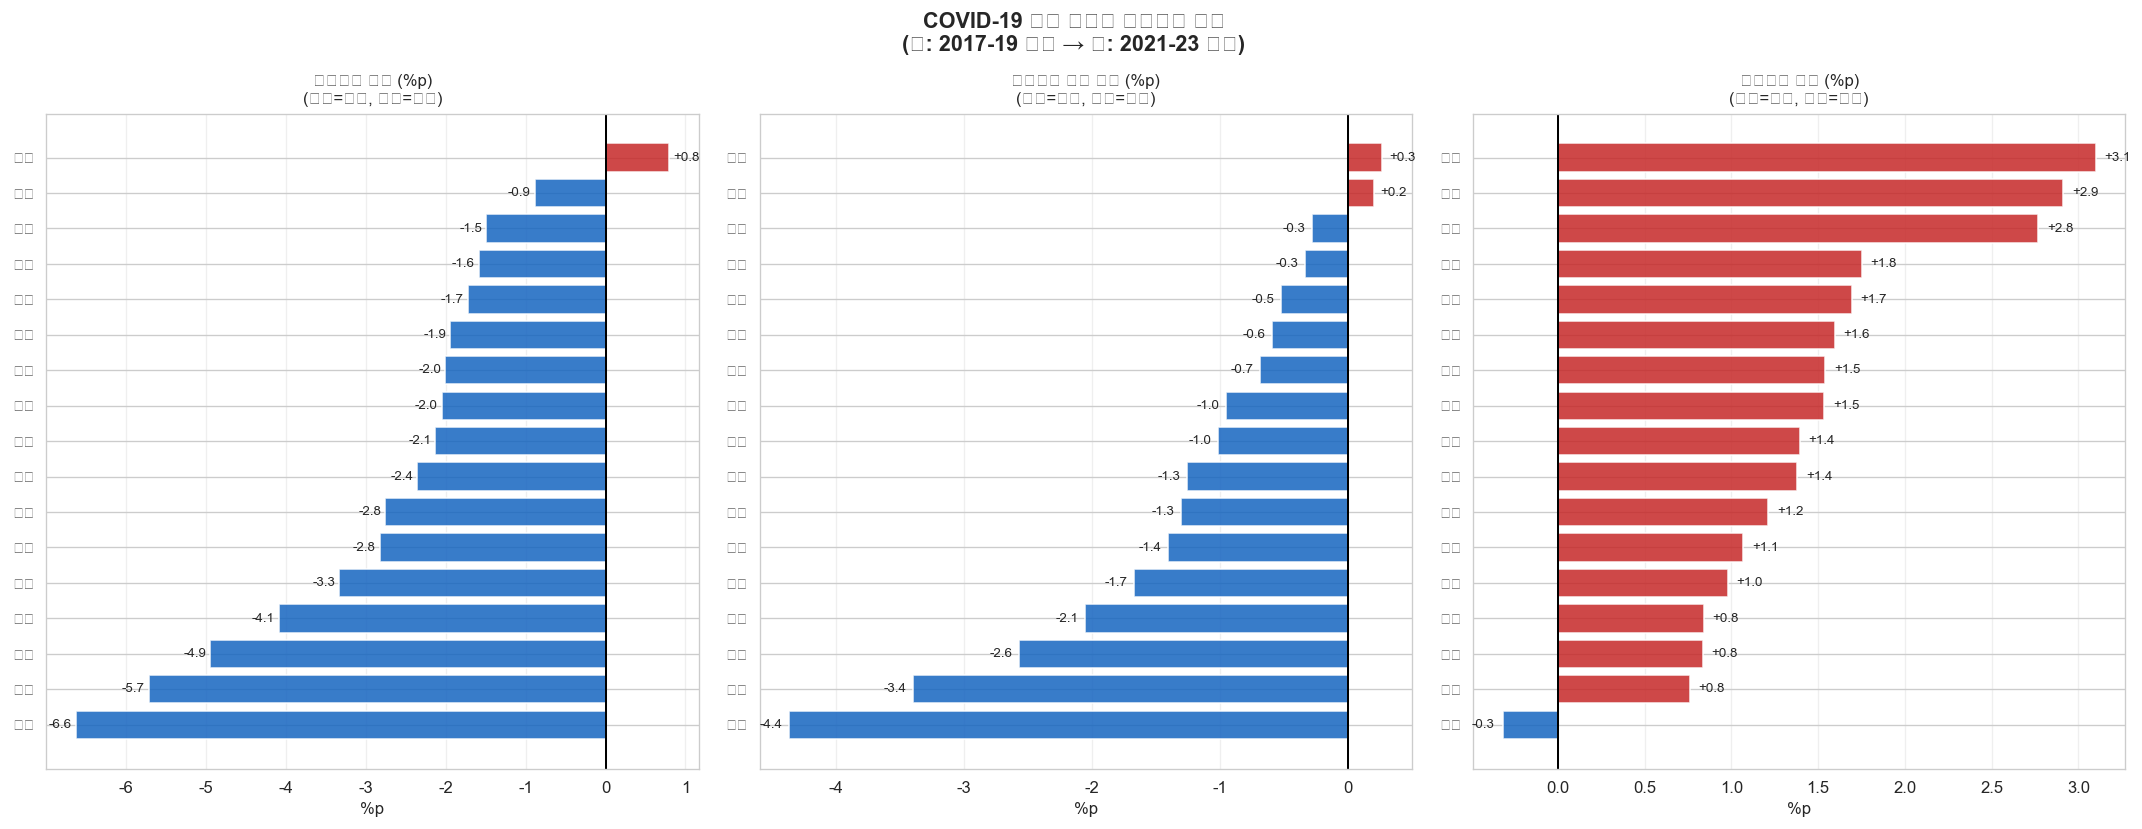


[COVID-19 전후 지역 간 격차 변화]
  건강나쁨           : 지역격차 17.7%p → 15.7%p (완화↓)
  스트레스_많음        : 지역격차 7.7%p → 5.7%p (완화↓)
  우울증상           : 지역격차 3.1%p → 2.5%p (완화↓)


In [34]:
# ⑥ COVID-19 전후 지역별 건강격차 변화
pre_covid  = df_all[df_all['year'].between(2017, 2019)]
post_covid = df_all[df_all['year'].between(2021, 2023)]

chg_cols = ['건강나쁨', '스트레스_많음', '우울증상']
pre_r    = pre_covid.groupby('지역')[chg_cols].mean().mul(100)
post_r   = post_covid.groupby('지역')[chg_cols].mean().mul(100)
change_r = (post_r - pre_r).dropna(how='all')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
chg_titles = ['건강나쁨 변화 (%p)', '스트레스 많음 변화 (%p)', '우울증상 변화 (%p)']

for ax, col, title in zip(axes, chg_cols, chg_titles):
    chg = change_r[col].sort_values()
    colors_chg = ['#C62828' if v > 0 else '#1565C0' for v in chg.values]
    bars = ax.barh(range(len(chg)), chg.values, color=colors_chg, alpha=0.85)
    ax.set_yticks(range(len(chg)))
    ax.set_yticklabels(chg.index, fontsize=9)
    ax.axvline(0, color='black', linewidth=1.2)
    for bar, val in zip(bars, chg.values):
        xpos = val + 0.05 if val >= 0 else val - 0.05
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha=ha, fontsize=8)
    ax.set_title(f'{title}\n(빨강=악화, 파랑=개선)', fontsize=10)
    ax.set_xlabel('%p')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('COVID-19 전후 지역별 건강지표 변화\n(전: 2017-19 평균 → 후: 2021-23 평균)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[COVID-19 전후 지역 간 격차 변화]")
for col in chg_cols:
    pre_gap  = pre_r[col].max()  - pre_r[col].min()
    post_gap = post_r[col].max() - post_r[col].min()
    print(f"  {col:15s}: 지역격차 {pre_gap:.1f}%p → {post_gap:.1f}%p "
          f"({'심화↑' if post_gap > pre_gap else '완화↓'})")